In [ ]:
print("IT WORKS")

IT WORKS


STAGE 1: ARTIFICIAL MISSINGNESS EXPERIMENT

[STEP 1] Loading the UPI daily dataset...
Dataset loaded successfully!
Shape: (1920, 3)
Columns: ['Day', 'Volume (In Mn.)', 'Value (In Cr.)']

[STEP 2] Preparing the dataset...
Date range: 2021-05-01 → 2026-08-02

Data types:
Day                datetime64[us]
Volume (In Mn.)           float64
Value (In Cr.)            float64
dtype: object

Missing values BEFORE artificial masking:
Day                0
Volume (In Mn.)    0
Value (In Cr.)     0
dtype: int64

Duplicate rows: 0

[STEP 3] Selecting numerical variables for imputation...
Variables selected:
  - Volume (In Mn.)
  - Value (In Cr.)

These two variables will be artificially masked.
The Day column will NOT be masked because it represents the time index.

[STEP 4] Creating the ground-truth dataset...
Ground-truth dataset stored.
These original values will be used to calculate:
  - RMSE
  - MAE
  - Distribution preservation
  - Variance preservation
  - Autocorrelation preservation

[STEP

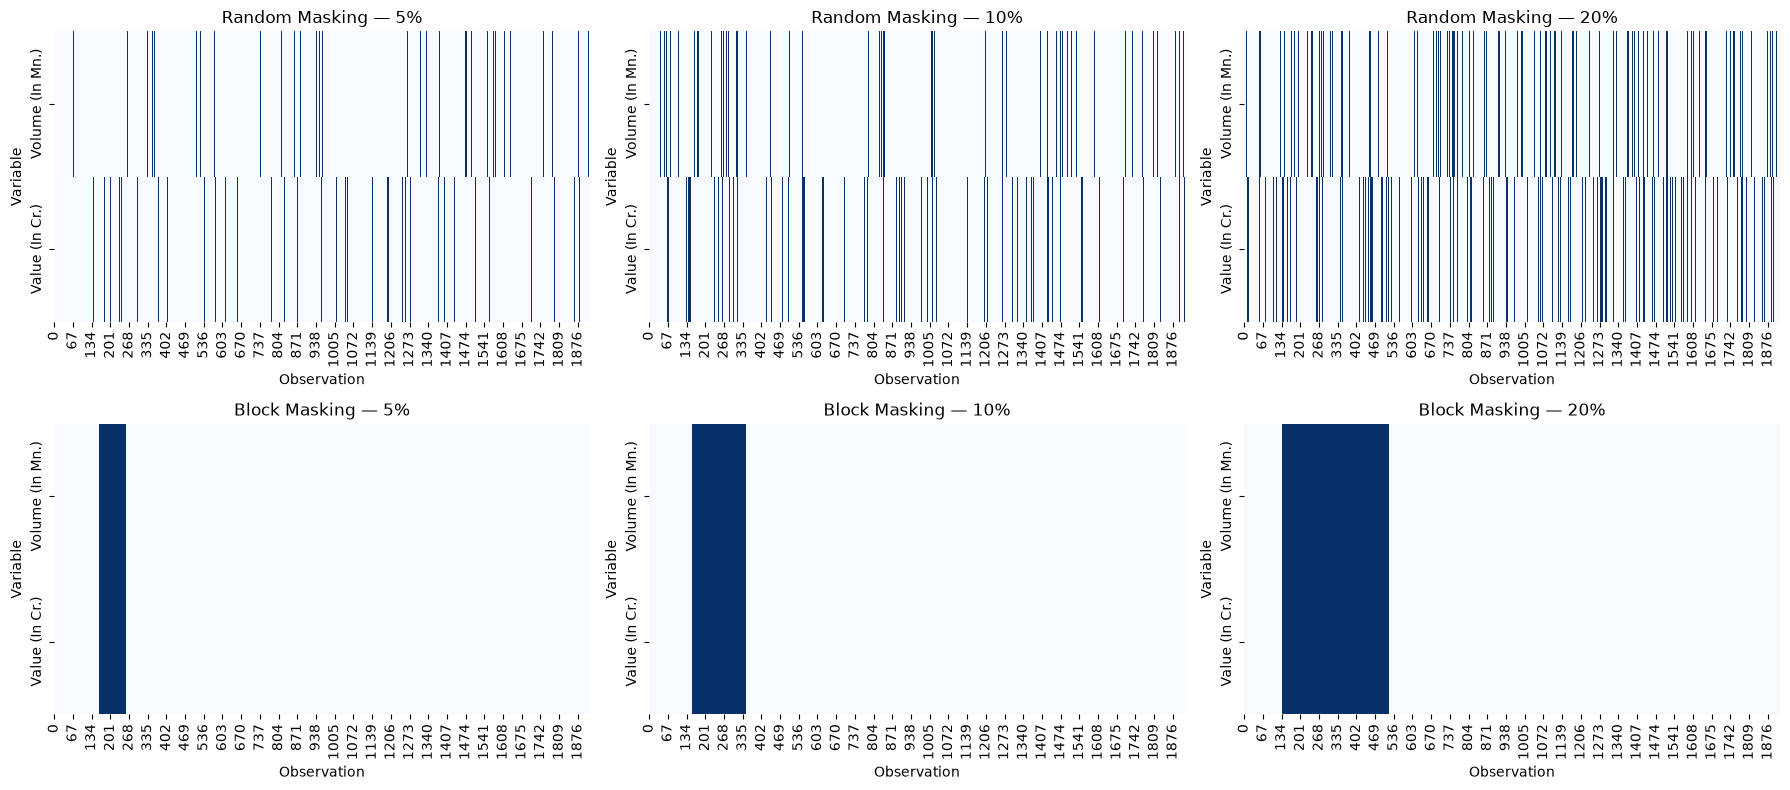


[STEP 13] Inspecting one masked dataset...

Example: RANDOM 10% masking
          Day  Volume (In Mn.)  Value (In Cr.)
0  2021-05-01            86.24        18140.21
1  2021-05-02            79.37        13692.47
2  2021-05-03            87.72        20191.07
3  2021-05-04            89.31        20005.02
4  2021-05-05            87.70        19438.15
5  2021-05-06            85.35        18425.68
6  2021-05-07            86.31        18247.77
7  2021-05-08            83.45        16365.41
8  2021-05-09            79.40        13425.59
9  2021-05-10            84.92        18772.21
10 2021-05-11              NaN        18267.37
11 2021-05-12            85.77        17402.93
12 2021-05-13            85.17        16038.79
13 2021-05-14              NaN        14038.22
14 2021-05-15            80.53        14824.99
15 2021-05-16            71.28        10804.95
16 2021-05-17            80.02        15977.60
17 2021-05-18            80.30        15314.82
18 2021-05-19            80.30    

In [ ]:
# ============================================================
# STAGE 1 — ARTIFICIAL MISSINGNESS / MASKING EXPERIMENT
# UPI Daily Statistics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("STAGE 1: ARTIFICIAL MISSINGNESS EXPERIMENT")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — LOAD THE DATASET
# ------------------------------------------------------------

print("\n[STEP 1] Loading the UPI daily dataset...")

file_path = "../datasets/upi_daily_stats_cleaned.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


# ------------------------------------------------------------
# STEP 2 — BASIC DATA PREPARATION
# ------------------------------------------------------------

print("\n[STEP 2] Preparing the dataset...")

# Convert Day to datetime
df["Day"] = pd.to_datetime(df["Day"])

# Sort chronologically
df = df.sort_values("Day").reset_index(drop=True)

print(f"Date range: {df['Day'].min().date()} → {df['Day'].max().date()}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values BEFORE artificial masking:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


# ------------------------------------------------------------
# STEP 3 — DEFINE THE VARIABLES WE WILL IMPUTE
# ------------------------------------------------------------

print("\n[STEP 3] Selecting numerical variables for imputation...")

target_columns = [
    "Volume (In Mn.)",
    "Value (In Cr.)"
]

print("Variables selected:")
for col in target_columns:
    print(f"  - {col}")

print("\nThese two variables will be artificially masked.")
print("The Day column will NOT be masked because it represents the time index.")


# ------------------------------------------------------------
# STEP 4 — CREATE A GROUND-TRUTH COPY
# ------------------------------------------------------------

print("\n[STEP 4] Creating the ground-truth dataset...")

# This is the untouched original dataset.
# We will later compare imputed values against these original values.

ground_truth = df.copy()

print("Ground-truth dataset stored.")
print("These original values will be used to calculate:")
print("  - RMSE")
print("  - MAE")
print("  - Distribution preservation")
print("  - Variance preservation")
print("  - Autocorrelation preservation")


# ------------------------------------------------------------
# STEP 5 — FUNCTION FOR RANDOM MASKING
# ------------------------------------------------------------

print("\n[STEP 5] Defining RANDOM masking function...")

def random_mask_data(data, columns, missing_fraction, random_state=42):
    """
    Randomly masks individual cells in the selected columns.

    Parameters:
        data            : original DataFrame
        columns         : columns to mask
        missing_fraction: proportion of cells to mask
        random_state    : seed for reproducibility

    Returns:
        masked_data     : DataFrame containing artificial NaNs
        mask            : Boolean DataFrame indicating masked cells
    """

    masked_data = data.copy()

    rng = np.random.default_rng(random_state)

    mask = pd.DataFrame(
        False,
        index=data.index,
        columns=columns
    )

    total_cells = len(data) * len(columns)

    n_to_mask = int(total_cells * missing_fraction)

    # Select random cell positions
    random_positions = rng.choice(
        total_cells,
        size=n_to_mask,
        replace=False
    )

    for position in random_positions:

        row = position // len(columns)
        col = position % len(columns)

        column_name = columns[col]

        mask.loc[row, column_name] = True
        masked_data.loc[row, column_name] = np.nan

    return masked_data, mask


print("Random masking function created.")


# ------------------------------------------------------------
# STEP 6 — FUNCTION FOR BLOCK MASKING
# ------------------------------------------------------------

print("\n[STEP 6] Defining BLOCK masking function...")

def block_mask_data(data, columns, missing_fraction, random_state=42):
    """
    Masks consecutive observations to simulate a data collection gap.

    The number of rows masked is determined by the missing fraction.
    Both selected numerical columns are masked for the same time period.
    """

    masked_data = data.copy()

    rng = np.random.default_rng(random_state)

    n_rows = len(data)

    block_length = max(
        1,
        int(n_rows * missing_fraction)
    )

    # Choose a valid starting position
    max_start = n_rows - block_length

    start = rng.integers(
        0,
        max_start + 1
    )

    end = start + block_length

    mask = pd.DataFrame(
        False,
        index=data.index,
        columns=columns
    )

    # Mask the same consecutive dates in both variables
    for column in columns:
        masked_data.loc[start:end-1, column] = np.nan
        mask.loc[start:end-1, column] = True

    return masked_data, mask


print("Block masking function created.")


# ------------------------------------------------------------
# STEP 7 — DEFINE EXPERIMENTAL MISSINGNESS LEVELS
# ------------------------------------------------------------

print("\n[STEP 7] Defining missingness levels...")

missingness_levels = [0.05, 0.10, 0.20]

print("Missingness levels:")
for level in missingness_levels:
    print(f"  - {int(level * 100)}%")


# ------------------------------------------------------------
# STEP 8 — CREATE RANDOM MASKING DATASETS
# ------------------------------------------------------------

print("\n[STEP 8] Creating RANDOM masking datasets...")

random_experiments = {}

for level in missingness_levels:

    percentage = int(level * 100)

    masked_data, mask = random_mask_data(
        ground_truth,
        target_columns,
        level,
        random_state=42
    )

    random_experiments[percentage] = {
        "data": masked_data,
        "mask": mask
    }

    actual_missing = masked_data[target_columns].isna().sum().sum()

    total_cells = len(masked_data) * len(target_columns)

    actual_percentage = (
        actual_missing / total_cells
    ) * 100

    print(
        f"  {percentage}% target → "
        f"{actual_missing} cells masked "
        f"({actual_percentage:.2f}% actual)"
    )


# ------------------------------------------------------------
# STEP 9 — CREATE BLOCK MASKING DATASETS
# ------------------------------------------------------------

print("\n[STEP 9] Creating BLOCK masking datasets...")

block_experiments = {}

for level in missingness_levels:

    percentage = int(level * 100)

    masked_data, mask = block_mask_data(
        ground_truth,
        target_columns,
        level,
        random_state=42
    )

    block_experiments[percentage] = {
        "data": masked_data,
        "mask": mask
    }

    actual_missing = masked_data[target_columns].isna().sum().sum()

    total_cells = len(masked_data) * len(target_columns)

    actual_percentage = (
        actual_missing / total_cells
    ) * 100

    start_index = mask.index[mask.any(axis=1)].min()
    end_index = mask.index[mask.any(axis=1)].max()

    print(
        f"  {percentage}% target → "
        f"{actual_missing} cells masked "
        f"({actual_percentage:.2f}% actual)"
    )

    print(
        f"       Block: "
        f"{ground_truth.loc[start_index, 'Day'].date()} → "
        f"{ground_truth.loc[end_index, 'Day'].date()}"
    )


# ------------------------------------------------------------
# STEP 10 — VERIFY RANDOM MASKING
# ------------------------------------------------------------

print("\n[STEP 10] Verifying RANDOM masking...")

for percentage, experiment in random_experiments.items():

    masked_data = experiment["data"]

    print(f"\n--- Random {percentage}% ---")

    print(
        masked_data[target_columns]
        .isna()
        .sum()
    )


# ------------------------------------------------------------
# STEP 11 — VERIFY BLOCK MASKING
# ------------------------------------------------------------

print("\n[STEP 11] Verifying BLOCK masking...")

for percentage, experiment in block_experiments.items():

    masked_data = experiment["data"]

    print(f"\n--- Block {percentage}% ---")

    print(
        masked_data[target_columns]
        .isna()
        .sum()
    )


# ------------------------------------------------------------
# STEP 12 — VISUALIZE THE MASKING PATTERNS
# ------------------------------------------------------------

print("\n[STEP 12] Visualizing artificial missingness...")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 8)
)

for i, percentage in enumerate(missingness_levels):

    percentage_int = int(percentage * 100)

    # Random masking
    random_mask = random_experiments[percentage_int]["mask"]

    sns.heatmap(
        random_mask.T,
        cmap="Blues",
        cbar=False,
        ax=axes[0, i]
    )

    axes[0, i].set_title(
        f"Random Masking — {percentage_int}%"
    )

    axes[0, i].set_xlabel("Observation")
    axes[0, i].set_ylabel("Variable")

    # Block masking
    block_mask = block_experiments[percentage_int]["mask"]

    sns.heatmap(
        block_mask.T,
        cmap="Blues",
        cbar=False,
        ax=axes[1, i]
    )

    axes[1, i].set_title(
        f"Block Masking — {percentage_int}%"
    )

    axes[1, i].set_xlabel("Observation")
    axes[1, i].set_ylabel("Variable")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 13 — SHOW AN EXAMPLE OF THE MASKED DATA
# ------------------------------------------------------------

print("\n[STEP 13] Inspecting one masked dataset...")

example_random = random_experiments[10]["data"]

print("\nExample: RANDOM 10% masking")
print(example_random.head(20))


# ------------------------------------------------------------
# STEP 14 — VERIFY GROUND TRUTH IS UNCHANGED
# ------------------------------------------------------------

print("\n[STEP 14] Verifying ground-truth dataset...")

print(
    "Missing values in ground truth:"
)

print(
    ground_truth[target_columns]
    .isna()
    .sum()
)

print(
    "\nGround truth remains completely intact."
)


# ------------------------------------------------------------
# STEP 15 — FINAL EXPERIMENT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 1 COMPLETE")
print("=" * 70)

print("\nExperimental setup created:")
print("  ✓ Original ground-truth dataset")
print("  ✓ Random masking: 5%, 10%, 20%")
print("  ✓ Block masking: 5%, 10%, 20%")
print("  ✓ Mask locations stored separately")
print("  ✓ Original values preserved for evaluation")
print("  ✓ Masking patterns visualized")

print("\nNext stage:")
print("  → Apply the four imputation techniques:")
print("      1. Mean / Median")
print("      2. KNN")
print("      3. MICE")
print("      4. Time-Series Interpolation")

print("\nAfter that:")
print("  → Compare imputed values against ground truth")
print("  → Calculate RMSE and MAE")
print("  → Evaluate distribution preservation")
print("  → Evaluate variance preservation")
print("  → Evaluate autocorrelation preservation")

print("\nReady for Stage 2: IMPUTATION.")
print("=" * 70)

STAGE 2: IMPUTATION TECHNIQUES

[STEP 1] Checking Stage 1 experimental data...
✓ Ground truth found
✓ Random masking experiments found
✓ Block masking experiments found
✓ Target columns found

[STEP 2] Loading imputation tools...
✓ KNN Imputer loaded
✓ MICE / Iterative Imputer loaded

[STEP 3] Defining Mean/Median imputation...
✓ Moving-window Mean/Median method defined
  Window size = 30 observations

[STEP 4] Defining KNN imputation...
✓ KNN method defined
  Number of neighbours (k) = 5
  Variables standardized before distance calculation

[STEP 5] Defining MICE imputation...
✓ MICE method defined
  Maximum iterations = 10
  Random state = 42

[STEP 6] Defining Time-Series interpolation...
✓ Time-Series interpolation defined
  Method = time-based linear interpolation

[STEP 7] Creating result storage...
✓ Result storage created

[STEP 8] Running imputations on RANDOM masking...
----------------------------------------------------------------------

>>> RANDOM MASKING — 5%
  [1/4] Mea

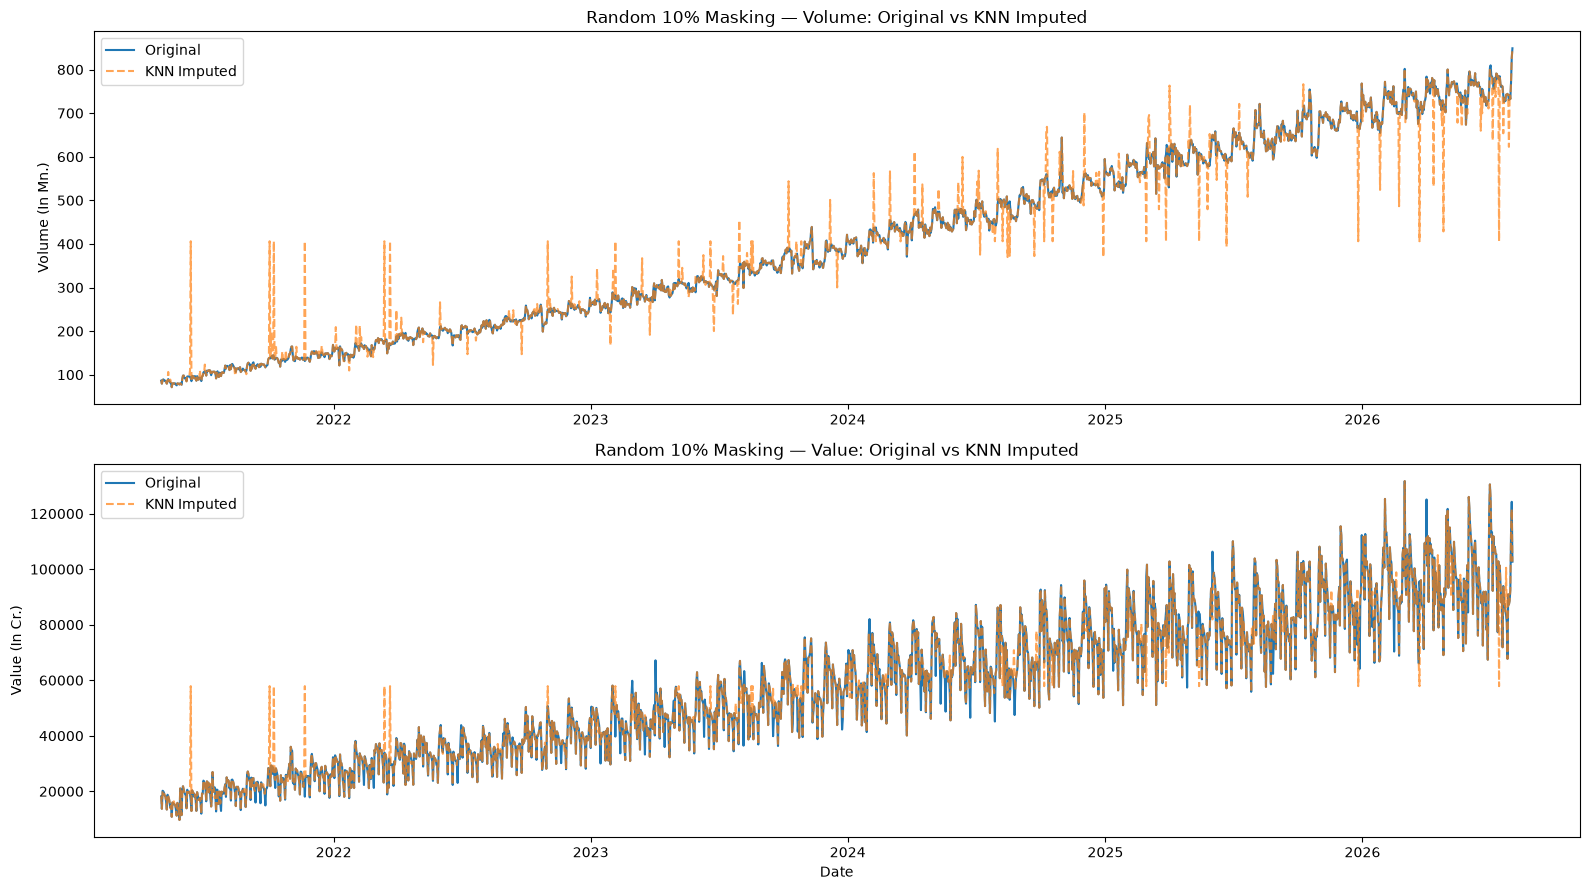


STAGE 2 COMPLETE

Imputation results generated for:
  Masking patterns:
    ✓ Random
    ✓ Block

  Missingness levels:
    ✓ 5%
    ✓ 10%
    ✓ 20%

  Imputation techniques:
    ✓ Mean
    ✓ Median
    ✓ KNN
    ✓ MICE
    ✓ Time-Series Interpolation

Total experimental combinations:
  2 masking patterns × 3 missingness levels × 5 methods
  = 30 imputation results

The original ground-truth data remains untouched.

NEXT STAGE:
  → Stage 3: Quantitative Evaluation
  → RMSE
  → MAE
  → KS statistic
  → Variance ratio
  → Autocorrelation preservation


In [ ]:
# ============================================================
# STAGE 2 — IMPUTATION
# Comparative Study of Missing Value Imputation Techniques
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("STAGE 2: IMPUTATION TECHNIQUES")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — CHECK THAT STAGE 1 VARIABLES EXIST
# ------------------------------------------------------------

print("\n[STEP 1] Checking Stage 1 experimental data...")

required_variables = [
    "ground_truth",
    "random_experiments",
    "block_experiments",
    "target_columns"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Stage 1 variables are missing: "
        + ", ".join(missing_variables)
        + "\nPlease run Stage 1 first."
    )

print("✓ Ground truth found")
print("✓ Random masking experiments found")
print("✓ Block masking experiments found")
print("✓ Target columns found")


# ------------------------------------------------------------
# STEP 2 — IMPORT IMPUTATION TOOLS
# ------------------------------------------------------------

print("\n[STEP 2] Loading imputation tools...")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print("✓ KNN Imputer loaded")
print("✓ MICE / Iterative Imputer loaded")


# ------------------------------------------------------------
# STEP 3 — DEFINE THE MEAN / MEDIAN IMPUTATION METHOD
# ------------------------------------------------------------

print("\n[STEP 3] Defining Mean/Median imputation...")

def moving_stat_imputation(data, columns, window=30, statistic="mean"):
    """
    Moving-window Mean/Median imputation.

    A centered rolling window is used to account for local
    time-series behaviour.

    If a value cannot be estimated from the local window,
    the overall column statistic is used as a fallback.
    """

    result = data.copy()

    for column in columns:

        # Calculate local moving statistic
        if statistic == "mean":
            local_stat = (
                result[column]
                .rolling(
                    window=window,
                    center=True,
                    min_periods=1
                )
                .mean()
            )

            global_stat = result[column].mean()

        elif statistic == "median":
            local_stat = (
                result[column]
                .rolling(
                    window=window,
                    center=True,
                    min_periods=1
                )
                .median()
            )

            global_stat = result[column].median()

        else:
            raise ValueError(
                "statistic must be 'mean' or 'median'"
            )

        # Fill missing values using local statistic
        result[column] = result[column].fillna(local_stat)

        # Global fallback
        result[column] = result[column].fillna(global_stat)

    return result


print("✓ Moving-window Mean/Median method defined")
print("  Window size = 30 observations")


# ------------------------------------------------------------
# STEP 4 — DEFINE KNN IMPUTATION
# ------------------------------------------------------------

print("\n[STEP 4] Defining KNN imputation...")

def knn_imputation(data, columns, n_neighbors=5):

    result = data.copy()

    # Work only with numerical variables
    numerical_data = result[columns].copy()

    # Standardize variables so that one variable does not
    # dominate the distance calculation
    scaler = StandardScaler()

    scaled_data = scaler.fit_transform(
        numerical_data
    )

    # Restore NaN positions after scaling
    scaled_data = pd.DataFrame(
        scaled_data,
        columns=columns,
        index=data.index
    )

    # KNN imputation
    imputer = KNNImputer(
        n_neighbors=n_neighbors
    )

    imputed_scaled = imputer.fit_transform(
        scaled_data
    )

    imputed_scaled = pd.DataFrame(
        imputed_scaled,
        columns=columns,
        index=data.index
    )

    # Convert back to original units
    imputed_values = scaler.inverse_transform(
        imputed_scaled
    )

    imputed_values = pd.DataFrame(
        imputed_values,
        columns=columns,
        index=data.index
    )

    # Put imputed values back into the complete dataset
    for column in columns:
        result[column] = imputed_values[column]

    return result


print("✓ KNN method defined")
print("  Number of neighbours (k) = 5")
print("  Variables standardized before distance calculation")


# ------------------------------------------------------------
# STEP 5 — DEFINE MICE IMPUTATION
# ------------------------------------------------------------

print("\n[STEP 5] Defining MICE imputation...")

def mice_imputation(data, columns):

    result = data.copy()

    numerical_data = result[columns].copy()

    # IterativeImputer performs chained iterative regression,
    # corresponding to the MICE approach used in the study.
    imputer = IterativeImputer(
        max_iter=10,
        random_state=42
    )

    imputed_values = imputer.fit_transform(
        numerical_data
    )

    imputed_values = pd.DataFrame(
        imputed_values,
        columns=columns,
        index=data.index
    )

    for column in columns:
        result[column] = imputed_values[column]

    return result


print("✓ MICE method defined")
print("  Maximum iterations = 10")
print("  Random state = 42")


# ------------------------------------------------------------
# STEP 6 — DEFINE TIME-SERIES INTERPOLATION
# ------------------------------------------------------------

print("\n[STEP 6] Defining Time-Series interpolation...")

def time_series_interpolation(data, columns):

    result = data.copy()

    # Day is our actual time index
    result = result.sort_values("Day").copy()

    result = result.set_index("Day")

    for column in columns:

        # Time-based linear interpolation
        result[column] = (
            result[column]
            .interpolate(
                method="time",
                limit_direction="both"
            )
        )

    result = result.reset_index()

    return result


print("✓ Time-Series interpolation defined")
print("  Method = time-based linear interpolation")


# ------------------------------------------------------------
# STEP 7 — CREATE STORAGE FOR ALL RESULTS
# ------------------------------------------------------------

print("\n[STEP 7] Creating result storage...")

imputation_results = {
    "random": {},
    "block": {}
}

print("✓ Result storage created")


# ------------------------------------------------------------
# STEP 8 — RUN IMPUTATION ON RANDOM MASKING DATA
# ------------------------------------------------------------

print("\n[STEP 8] Running imputations on RANDOM masking...")
print("-" * 70)

for percentage in [5, 10, 20]:

    print(f"\n>>> RANDOM MASKING — {percentage}%")

    masked_data = random_experiments[percentage]["data"]

    imputation_results["random"][percentage] = {}

    # -------------------------
    # Mean
    # -------------------------

    print("  [1/4] Mean imputation...")

    mean_result = moving_stat_imputation(
        masked_data,
        target_columns,
        window=30,
        statistic="mean"
    )

    imputation_results["random"][percentage]["mean"] = mean_result

    print("       ✓ Complete")


    # -------------------------
    # Median
    # -------------------------

    print("  [2/4] Median imputation...")

    median_result = moving_stat_imputation(
        masked_data,
        target_columns,
        window=30,
        statistic="median"
    )

    imputation_results["random"][percentage]["median"] = median_result

    print("       ✓ Complete")


    # -------------------------
    # KNN
    # -------------------------

    print("  [3/4] KNN imputation...")

    knn_result = knn_imputation(
        masked_data,
        target_columns,
        n_neighbors=5
    )

    imputation_results["random"][percentage]["knn"] = knn_result

    print("       ✓ Complete")


    # -------------------------
    # MICE
    # -------------------------

    print("  [4/4] MICE imputation...")

    mice_result = mice_imputation(
        masked_data,
        target_columns
    )

    imputation_results["random"][percentage]["mice"] = mice_result

    print("       ✓ Complete")


    # -------------------------
    # Time-Series Interpolation
    # -------------------------

    print("  [5/5] Time-Series interpolation...")

    interpolation_result = time_series_interpolation(
        masked_data,
        target_columns
    )

    imputation_results["random"][percentage]["interpolation"] = (
        interpolation_result
    )

    print("       ✓ Complete")


# ------------------------------------------------------------
# STEP 9 — RUN IMPUTATION ON BLOCK MASKING DATA
# ------------------------------------------------------------

print("\n[STEP 9] Running imputations on BLOCK masking...")
print("-" * 70)

for percentage in [5, 10, 20]:

    print(f"\n>>> BLOCK MASKING — {percentage}%")

    masked_data = block_experiments[percentage]["data"]

    imputation_results["block"][percentage] = {}


    # -------------------------
    # Mean
    # -------------------------

    print("  [1/5] Mean imputation...")

    mean_result = moving_stat_imputation(
        masked_data,
        target_columns,
        window=30,
        statistic="mean"
    )

    imputation_results["block"][percentage]["mean"] = mean_result

    print("       ✓ Complete")


    # -------------------------
    # Median
    # -------------------------

    print("  [2/5] Median imputation...")

    median_result = moving_stat_imputation(
        masked_data,
        target_columns,
        window=30,
        statistic="median"
    )

    imputation_results["block"][percentage]["median"] = median_result

    print("       ✓ Complete")


    # -------------------------
    # KNN
    # -------------------------

    print("  [3/5] KNN imputation...")

    knn_result = knn_imputation(
        masked_data,
        target_columns,
        n_neighbors=5
    )

    imputation_results["block"][percentage]["knn"] = knn_result

    print("       ✓ Complete")


    # -------------------------
    # MICE
    # -------------------------

    print("  [4/5] MICE imputation...")

    mice_result = mice_imputation(
        masked_data,
        target_columns
    )

    imputation_results["block"][percentage]["mice"] = mice_result

    print("       ✓ Complete")


    # -------------------------
    # Time-Series Interpolation
    # -------------------------

    print("  [5/5] Time-Series interpolation...")

    interpolation_result = time_series_interpolation(
        masked_data,
        target_columns
    )

    imputation_results["block"][percentage]["interpolation"] = (
        interpolation_result
    )

    print("       ✓ Complete")


# ------------------------------------------------------------
# STEP 10 — VERIFY THAT IMPUTATION REMOVED ALL NaNs
# ------------------------------------------------------------

print("\n[STEP 10] Checking imputation completeness...")
print("-" * 70)

methods = [
    "mean",
    "median",
    "knn",
    "mice",
    "interpolation"
]

for masking_type in ["random", "block"]:

    for percentage in [5, 10, 20]:

        print(
            f"\n{masking_type.upper()} {percentage}%:"
        )

        for method in methods:

            result = (
                imputation_results
                [masking_type]
                [percentage]
                [method]
            )

            remaining_missing = (
                result[target_columns]
                .isna()
                .sum()
                .sum()
            )

            print(
                f"  {method:<15} "
                f"remaining NaNs = {remaining_missing}"
            )


# ------------------------------------------------------------
# STEP 11 — INSPECT ONE EXAMPLE
# ------------------------------------------------------------

print("\n[STEP 11] Inspecting an example of imputation...")
print("-" * 70)

# Choose Random 10%
percentage = 10

masked_example = random_experiments[percentage]["data"]

imputed_example = (
    imputation_results
    ["random"]
    [percentage]
    ["knn"]
)

# Find locations that were artificially masked
mask = random_experiments[percentage]["mask"]

masked_indices = mask.any(axis=1)

comparison = pd.DataFrame({
    "Day": ground_truth.loc[masked_indices, "Day"],
    "Original Volume": ground_truth.loc[
        masked_indices,
        "Volume (In Mn.)"
    ],
    "KNN Volume": imputed_example.loc[
        masked_indices,
        "Volume (In Mn.)"
    ],
    "Original Value": ground_truth.loc[
        masked_indices,
        "Value (In Cr.)"
    ],
    "KNN Value": imputed_example.loc[
        masked_indices,
        "Value (In Cr.)"
    ]
})

print("\nFirst 10 artificially masked observations")
print("and their KNN-imputed values:\n")

print(
    comparison.head(10).to_string(index=False)
)


# ------------------------------------------------------------
# STEP 12 — VISUALIZE ORIGINAL VS IMPUTED
# ------------------------------------------------------------

print("\n[STEP 12] Visualizing original vs KNN-imputed data...")

# Use Random 10% example
original = ground_truth
knn_result = imputation_results["random"][10]["knn"]
mask = random_experiments[10]["mask"]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 9)
)

# Volume
axes[0].plot(
    original["Day"],
    original["Volume (In Mn.)"],
    label="Original"
)

axes[0].plot(
    knn_result["Day"],
    knn_result["Volume (In Mn.)"],
    linestyle="--",
    alpha=0.7,
    label="KNN Imputed"
)

axes[0].set_title(
    "Random 10% Masking — Volume: Original vs KNN Imputed"
)

axes[0].set_ylabel("Volume (In Mn.)")
axes[0].legend()


# Value
axes[1].plot(
    original["Day"],
    original["Value (In Cr.)"],
    label="Original"
)

axes[1].plot(
    knn_result["Day"],
    knn_result["Value (In Cr.)"],
    linestyle="--",
    alpha=0.7,
    label="KNN Imputed"
)

axes[1].set_title(
    "Random 10% Masking — Value: Original vs KNN Imputed"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value (In Cr.)")
axes[1].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 13 — FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 2 COMPLETE")
print("=" * 70)

print("\nImputation results generated for:")

print("  Masking patterns:")
print("    ✓ Random")
print("    ✓ Block")

print("\n  Missingness levels:")
print("    ✓ 5%")
print("    ✓ 10%")
print("    ✓ 20%")

print("\n  Imputation techniques:")
print("    ✓ Mean")
print("    ✓ Median")
print("    ✓ KNN")
print("    ✓ MICE")
print("    ✓ Time-Series Interpolation")

print("\nTotal experimental combinations:")
print("  2 masking patterns × 3 missingness levels × 5 methods")
print("  = 30 imputation results")

print("\nThe original ground-truth data remains untouched.")

print("\nNEXT STAGE:")
print("  → Stage 3: Quantitative Evaluation")
print("  → RMSE")
print("  → MAE")
print("  → KS statistic")
print("  → Variance ratio")
print("  → Autocorrelation preservation")

print("=" * 70)

In [ ]:
print("ground_truth:", "ground_truth" in globals())
print("target_columns:", "target_columns" in globals())
print("random_experiments:", "random_experiments" in globals())
print("block_experiments:", "block_experiments" in globals())

ground_truth: True
target_columns: True
random_experiments: True
block_experiments: True


STAGE 3A: RMSE AND MAE EVALUATION

[STEP 1] Checking experimental results...
✓ Stage 2 imputation results found
✓ Ground-truth dataset found
✓ Mask information found

[STEP 2] Defining RMSE and MAE evaluation...
✓ Evaluation function created
✓ Only artificially masked cells will be evaluated

[STEP 3] Evaluating all imputation experiments...
----------------------------------------------------------------------

RANDOM MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

✓ All experiments evaluated

[STEP 4] Complete RMSE + M

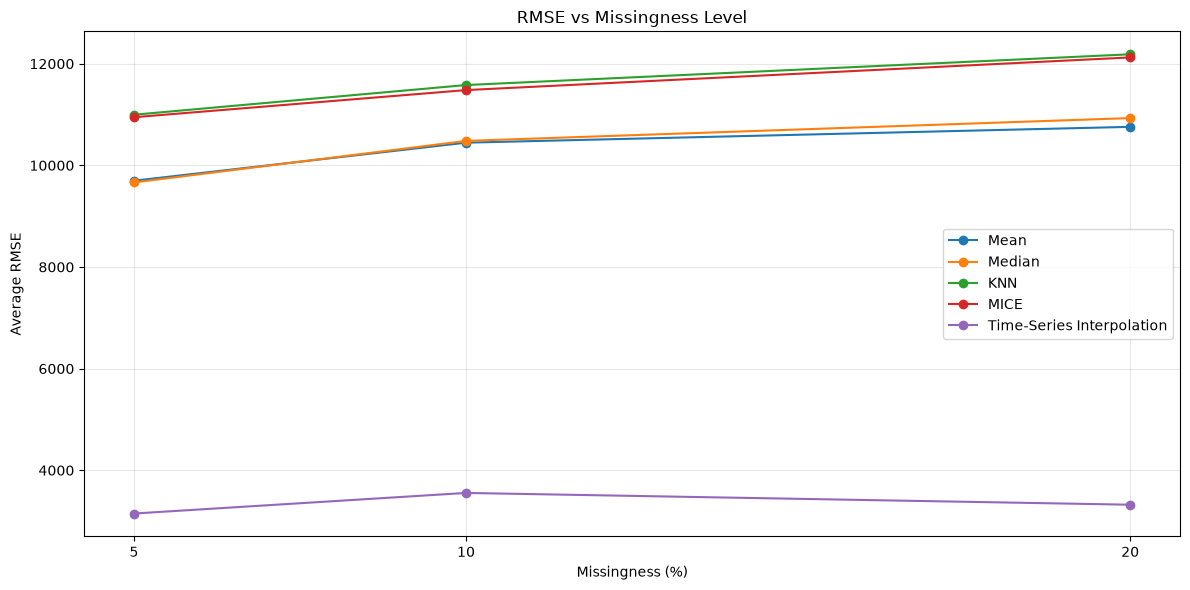


[STEP 11] Creating MAE comparison plot...


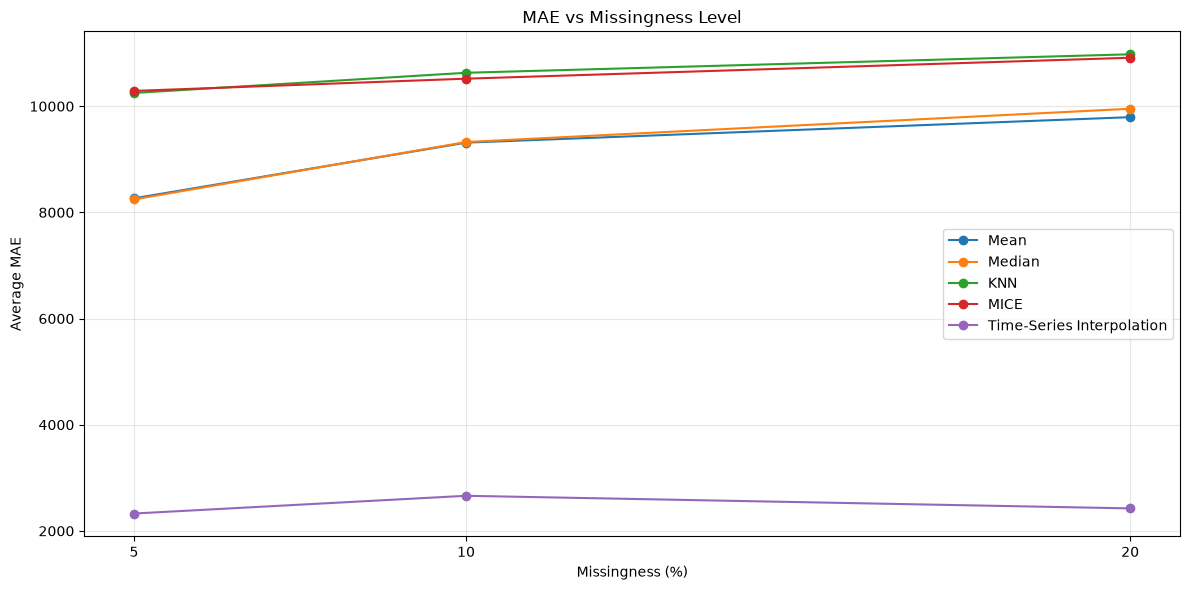


[STEP 12] Comparing random and block masking...
Masking                    Method         RMSE          MAE
  block                       KNN 17234.612031 17036.441449
  block                      MICE 17234.612031 17036.441449
  block                      Mean 15678.642072 14482.977155
  block                    Median 15720.395500 14522.475349
  block Time-Series Interpolation  2676.915786  2118.902206
 random                       KNN  5939.305452  4202.867921
 random                      MICE  5799.383542  4110.878982
 random                      Mean  4921.649542  3766.509934
 random                    Median  4995.594602  3826.211719
 random Time-Series Interpolation  4005.662155  2822.624424

[STEP 13] Saving evaluation tables...
✓ evaluation_results_df
✓ overall_results_df
✓ rmse_pivot_df
✓ mae_pivot_df

STAGE 3A COMPLETE

Metrics calculated:
  ✓ RMSE
  ✓ MAE

Evaluation was performed ONLY on artificially masked cells.

Experiments evaluated:
  ✓ Random masking — 5%, 10%, 20%


In [ ]:
# ============================================================
# STAGE 3A — QUANTITATIVE EVALUATION
# RMSE + MAE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

print("=" * 70)
print("STAGE 3A: RMSE AND MAE EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — CHECK REQUIRED DATA
# ------------------------------------------------------------

print("\n[STEP 1] Checking experimental results...")

if "imputation_results" not in globals():
    raise RuntimeError(
        "Stage 2 results not found. Please run Stage 2 first."
    )

print("✓ Stage 2 imputation results found")
print("✓ Ground-truth dataset found")
print("✓ Mask information found")


# ------------------------------------------------------------
# STEP 2 — DEFINE THE EVALUATION FUNCTION
# ------------------------------------------------------------

print("\n[STEP 2] Defining RMSE and MAE evaluation...")

def evaluate_imputation(
    ground_truth,
    imputed_data,
    mask,
    columns
):
    """
    Calculate RMSE and MAE ONLY on artificially masked cells.

    This is critical because unmasked observations were never
    imputed and therefore should not contribute to the error.
    """

    results = []

    for column in columns:

        # Identify only the cells that were artificially masked
        masked_positions = mask[column]

        actual = ground_truth.loc[
            masked_positions,
            column
        ]

        predicted = imputed_data.loc[
            masked_positions,
            column
        ]

        # Calculate errors
        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        mae = mean_absolute_error(
            actual,
            predicted
        )

        results.append({
            "Variable": column,
            "RMSE": rmse,
            "MAE": mae,
            "N_Masked": len(actual)
        })

    return pd.DataFrame(results)


print("✓ Evaluation function created")
print("✓ Only artificially masked cells will be evaluated")


# ------------------------------------------------------------
# STEP 3 — EVALUATE ALL EXPERIMENTS
# ------------------------------------------------------------

print("\n[STEP 3] Evaluating all imputation experiments...")
print("-" * 70)

evaluation_results = []

methods = [
    "mean",
    "median",
    "knn",
    "mice",
    "interpolation"
]

method_labels = {
    "mean": "Mean",
    "median": "Median",
    "knn": "KNN",
    "mice": "MICE",
    "interpolation": "Time-Series Interpolation"
}


for masking_type in ["random", "block"]:

    for percentage in [5, 10, 20]:

        print(
            f"\n{masking_type.upper()} MASKING — {percentage}%"
        )

        # Get mask
        mask = (
            random_experiments[percentage]["mask"]
            if masking_type == "random"
            else block_experiments[percentage]["mask"]
        )

        # Evaluate every method
        for method in methods:

            imputed_data = (
                imputation_results
                [masking_type]
                [percentage]
                [method]
            )

            method_results = evaluate_imputation(
                ground_truth,
                imputed_data,
                mask,
                target_columns
            )

            # Store results for each variable
            for _, row in method_results.iterrows():

                evaluation_results.append({

                    "Masking": masking_type,
                    "Missingness": percentage,
                    "Method": method_labels[method],
                    "Variable": row["Variable"],
                    "RMSE": row["RMSE"],
                    "MAE": row["MAE"],
                    "N_Masked": row["N_Masked"]

                })

            print(
                f"  ✓ {method_labels[method]}"
            )


# Convert results to DataFrame
evaluation_df = pd.DataFrame(
    evaluation_results
)

print("\n✓ All experiments evaluated")


# ------------------------------------------------------------
# STEP 4 — DISPLAY COMPLETE RESULTS
# ------------------------------------------------------------

print("\n[STEP 4] Complete RMSE + MAE results")
print("=" * 70)

print(
    evaluation_df.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 5 — CREATE AVERAGE PERFORMANCE TABLE
# ------------------------------------------------------------

print("\n[STEP 5] Creating overall method comparison...")

overall_results = (
    evaluation_df
    .groupby("Method")
    [["RMSE", "MAE"]]
    .mean()
    .sort_values("RMSE")
)

print("\nAverage performance across ALL experiments:")
print()

print(
    overall_results.to_string()
)


# ------------------------------------------------------------
# STEP 6 — RANK METHODS BY RMSE
# ------------------------------------------------------------

print("\n[STEP 6] Ranking methods by RMSE...")

rmse_ranking = (
    overall_results
    .sort_values("RMSE")
    .copy()
)

rmse_ranking["RMSE Rank"] = (
    range(1, len(rmse_ranking) + 1)
)

print(
    rmse_ranking.to_string()
)

print(
    f"\n🏆 Best overall RMSE method: "
    f"{rmse_ranking.index[0]}"
)


# ------------------------------------------------------------
# STEP 7 — RANK METHODS BY MAE
# ------------------------------------------------------------

print("\n[STEP 7] Ranking methods by MAE...")

mae_ranking = (
    overall_results
    .sort_values("MAE")
    .copy()
)

mae_ranking["MAE Rank"] = (
    range(1, len(mae_ranking) + 1)
)

print(
    mae_ranking.to_string()
)

print(
    f"\n🏆 Best overall MAE method: "
    f"{mae_ranking.index[0]}"
)


# ------------------------------------------------------------
# STEP 8 — RMSE BY MISSINGNESS LEVEL
# ------------------------------------------------------------

print("\n[STEP 8] Comparing RMSE across missingness levels...")

rmse_by_missingness = (
    evaluation_df
    .groupby(
        ["Missingness", "Method"]
    )["RMSE"]
    .mean()
    .reset_index()
)

rmse_pivot = (
    rmse_by_missingness
    .pivot(
        index="Missingness",
        columns="Method",
        values="RMSE"
    )
)

print("\nRMSE by missingness level:")
print(
    rmse_pivot.to_string()
)


# ------------------------------------------------------------
# STEP 9 — MAE BY MISSINGNESS LEVEL
# ------------------------------------------------------------

print("\n[STEP 9] Comparing MAE across missingness levels...")

mae_by_missingness = (
    evaluation_df
    .groupby(
        ["Missingness", "Method"]
    )["MAE"]
    .mean()
    .reset_index()
)

mae_pivot = (
    mae_by_missingness
    .pivot(
        index="Missingness",
        columns="Method",
        values="MAE"
    )
)

print("\nMAE by missingness level:")
print(
    mae_pivot.to_string()
)


# ------------------------------------------------------------
# STEP 10 — RMSE VISUALIZATION
# ------------------------------------------------------------

print("\n[STEP 10] Creating RMSE comparison plot...")

plt.figure(figsize=(12, 6))

for method in method_labels.values():

    method_data = (
        rmse_by_missingness[
            rmse_by_missingness["Method"] == method
        ]
    )

    plt.plot(
        method_data["Missingness"],
        method_data["RMSE"],
        marker="o",
        label=method
    )

plt.xlabel("Missingness (%)")
plt.ylabel("Average RMSE")
plt.title(
    "RMSE vs Missingness Level"
)

plt.xticks([5, 10, 20])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 11 — MAE VISUALIZATION
# ------------------------------------------------------------

print("\n[STEP 11] Creating MAE comparison plot...")

plt.figure(figsize=(12, 6))

for method in method_labels.values():

    method_data = (
        mae_by_missingness[
            mae_by_missingness["Method"] == method
        ]
    )

    plt.plot(
        method_data["Missingness"],
        method_data["MAE"],
        marker="o",
        label=method
    )

plt.xlabel("Missingness (%)")
plt.ylabel("Average MAE")
plt.title(
    "MAE vs Missingness Level"
)

plt.xticks([5, 10, 20])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 12 — COMPARE RANDOM VS BLOCK MASKING
# ------------------------------------------------------------

print("\n[STEP 12] Comparing random and block masking...")

masking_comparison = (
    evaluation_df
    .groupby(
        ["Masking", "Method"]
    )[["RMSE", "MAE"]]
    .mean()
    .reset_index()
)

print(
    masking_comparison.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 13 — SAVE RESULTS IN MEMORY
# ------------------------------------------------------------

print("\n[STEP 13] Saving evaluation tables...")

# Keep these variables available for Stage 3B
evaluation_results_df = evaluation_df.copy()
overall_results_df = overall_results.copy()
rmse_pivot_df = rmse_pivot.copy()
mae_pivot_df = mae_pivot.copy()

print("✓ evaluation_results_df")
print("✓ overall_results_df")
print("✓ rmse_pivot_df")
print("✓ mae_pivot_df")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3A COMPLETE")
print("=" * 70)

print("\nMetrics calculated:")
print("  ✓ RMSE")
print("  ✓ MAE")

print("\nEvaluation was performed ONLY on artificially masked cells.")

print("\nExperiments evaluated:")
print("  ✓ Random masking — 5%, 10%, 20%")
print("  ✓ Block masking — 5%, 10%, 20%")

print("\nMethods evaluated:")
print("  ✓ Mean")
print("  ✓ Median")
print("  ✓ KNN")
print("  ✓ MICE")
print("  ✓ Time-Series Interpolation")

print("\nNEXT:")
print("  → Stage 3B: Distribution Preservation")
print("  → KS Statistic")
print("  → Variance Ratio")

print("=" * 70)

STAGE 3B: DISTRIBUTION PRESERVATION

[STEP 1] Checking previous-stage results...
✓ Stage 2 results found
✓ Stage 3A results found
✓ Ground truth found

[STEP 2] Defining distribution-preservation metrics...
✓ KS statistic defined
✓ KS p-value defined
✓ Variance ratio defined

[STEP 3] Evaluating distribution preservation...
----------------------------------------------------------------------

RANDOM MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

✓ Distribution evaluation complete

[STEP 4] Complete distribution result

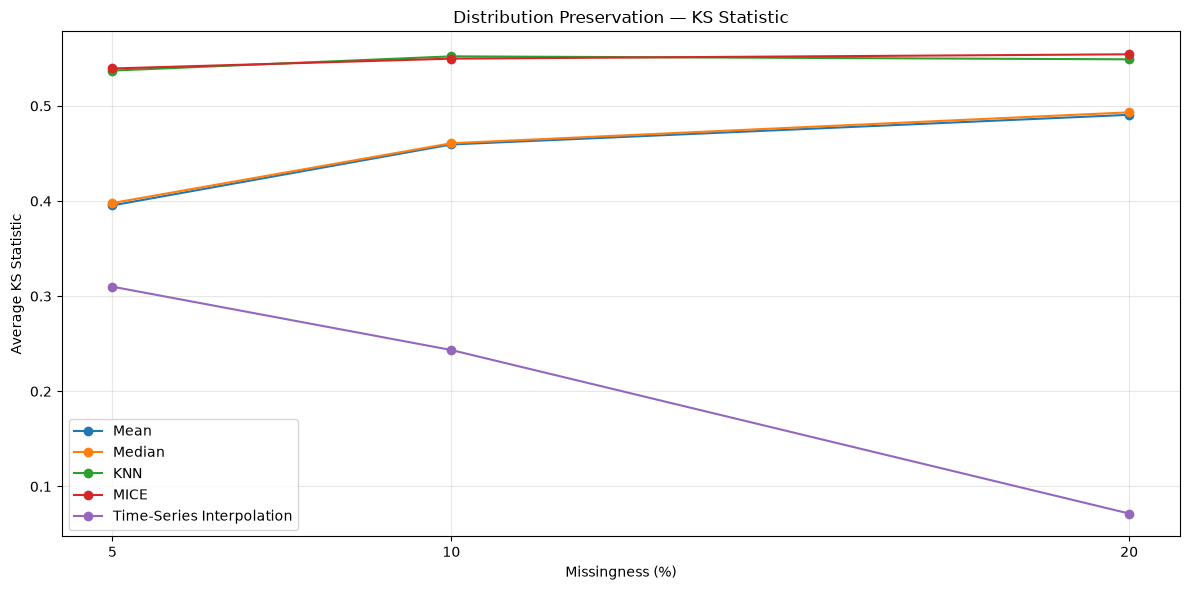


[STEP 9] Creating variance ratio comparison...


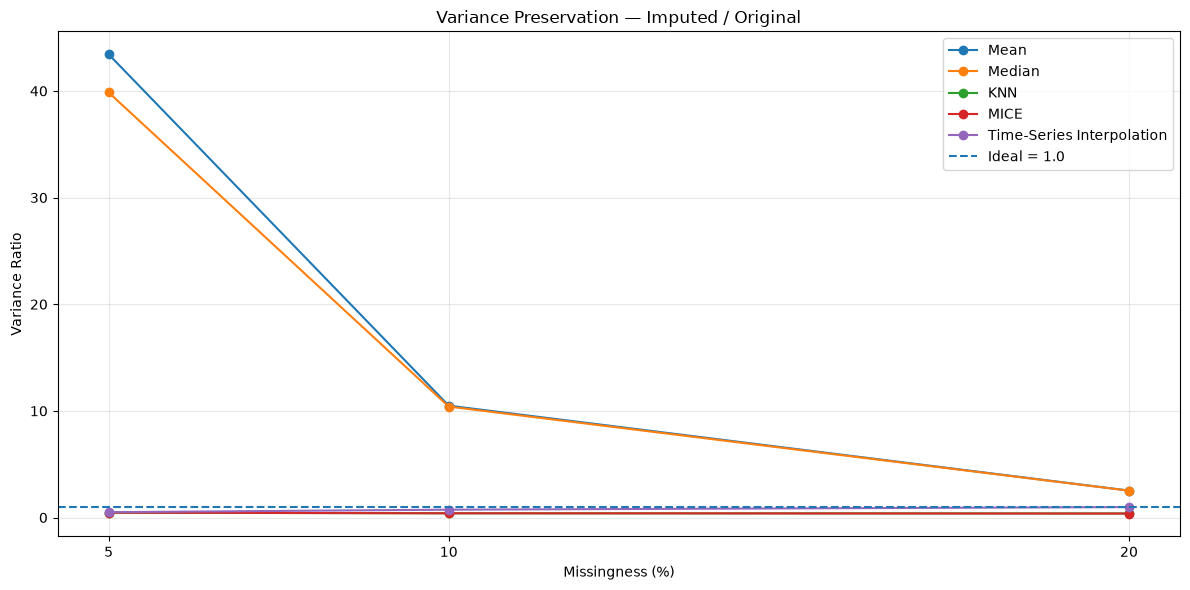


[STEP 10] Comparing masking patterns...
Masking                    Method        Variable  KS Statistic  Variance Ratio
  block                       KNN  Value (In Cr.)      1.000000    4.872540e-30
  block                       KNN Volume (In Mn.)      1.000000    7.904508e-30
  block                      MICE  Value (In Cr.)      1.000000    4.872540e-30
  block                      MICE Volume (In Mn.)      1.000000    7.904508e-30
  block                      Mean  Value (In Cr.)      0.823785    7.777691e+00
  block                      Mean Volume (In Mn.)      0.837674    6.563901e+01
  block                    Median  Value (In Cr.)      0.823785    7.361403e+00
  block                    Median Volume (In Mn.)      0.839410    6.118716e+01
  block Time-Series Interpolation  Value (In Cr.)      0.468750    3.333814e-01
  block Time-Series Interpolation Volume (In Mn.)      0.286458    6.957774e-01
 random                       KNN  Value (In Cr.)      0.083031    8.061240e-01

In [ ]:
# ============================================================
# STAGE 3B — DISTRIBUTION PRESERVATION
# KS STATISTIC + VARIANCE RATIO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

print("=" * 70)
print("STAGE 3B: DISTRIBUTION PRESERVATION")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — CHECK REQUIRED DATA
# ------------------------------------------------------------

print("\n[STEP 1] Checking previous-stage results...")

if "imputation_results" not in globals():
    raise RuntimeError(
        "Stage 2 results not found."
    )

if "evaluation_results_df" not in globals():
    raise RuntimeError(
        "Stage 3A results not found. "
        "Please run Stage 3A first."
    )

print("✓ Stage 2 results found")
print("✓ Stage 3A results found")
print("✓ Ground truth found")


# ------------------------------------------------------------
# STEP 2 — DEFINE DISTRIBUTION EVALUATION
# ------------------------------------------------------------

print("\n[STEP 2] Defining distribution-preservation metrics...")

def evaluate_distribution(
    ground_truth,
    imputed_data,
    mask,
    columns
):
    """
    Evaluate distribution preservation on the artificially
    masked observations.

    Metrics:
        KS statistic
        Variance ratio
    """

    results = []

    for column in columns:

        masked_positions = mask[column]

        # Original values that were hidden
        original_values = ground_truth.loc[
            masked_positions,
            column
        ].dropna()

        # Corresponding imputed values
        imputed_values = imputed_data.loc[
            masked_positions,
            column
        ].dropna()

        # ----------------------------------------------------
        # KS STATISTIC
        # ----------------------------------------------------

        ks_statistic, ks_pvalue = ks_2samp(
            original_values,
            imputed_values
        )

        # ----------------------------------------------------
        # VARIANCE RATIO
        # ----------------------------------------------------

        original_variance = np.var(
            original_values,
            ddof=1
        )

        imputed_variance = np.var(
            imputed_values,
            ddof=1
        )

        if original_variance == 0:
            variance_ratio = np.nan
        else:
            variance_ratio = (
                imputed_variance /
                original_variance
            )

        results.append({
            "Variable": column,
            "KS Statistic": ks_statistic,
            "KS p-value": ks_pvalue,
            "Original Variance": original_variance,
            "Imputed Variance": imputed_variance,
            "Variance Ratio": variance_ratio
        })

    return pd.DataFrame(results)


print("✓ KS statistic defined")
print("✓ KS p-value defined")
print("✓ Variance ratio defined")


# ------------------------------------------------------------
# STEP 3 — EVALUATE ALL EXPERIMENTS
# ------------------------------------------------------------

print("\n[STEP 3] Evaluating distribution preservation...")
print("-" * 70)

distribution_results = []

methods = [
    "mean",
    "median",
    "knn",
    "mice",
    "interpolation"
]

method_labels = {
    "mean": "Mean",
    "median": "Median",
    "knn": "KNN",
    "mice": "MICE",
    "interpolation": "Time-Series Interpolation"
}


for masking_type in ["random", "block"]:

    for percentage in [5, 10, 20]:

        print(
            f"\n{masking_type.upper()} MASKING — {percentage}%"
        )

        # Select correct mask
        if masking_type == "random":
            mask = random_experiments[
                percentage
            ]["mask"]
        else:
            mask = block_experiments[
                percentage
            ]["mask"]

        for method in methods:

            imputed_data = (
                imputation_results
                [masking_type]
                [percentage]
                [method]
            )

            method_results = evaluate_distribution(
                ground_truth,
                imputed_data,
                mask,
                target_columns
            )

            for _, row in method_results.iterrows():

                distribution_results.append({

                    "Masking": masking_type,
                    "Missingness": percentage,
                    "Method": method_labels[method],
                    "Variable": row["Variable"],
                    "KS Statistic": row["KS Statistic"],
                    "KS p-value": row["KS p-value"],
                    "Original Variance": row[
                        "Original Variance"
                    ],
                    "Imputed Variance": row[
                        "Imputed Variance"
                    ],
                    "Variance Ratio": row[
                        "Variance Ratio"
                    ]

                })

            print(
                f"  ✓ {method_labels[method]}"
            )


distribution_df = pd.DataFrame(
    distribution_results
)

print("\n✓ Distribution evaluation complete")


# ------------------------------------------------------------
# STEP 4 — DISPLAY COMPLETE RESULTS
# ------------------------------------------------------------

print("\n[STEP 4] Complete distribution results")
print("=" * 70)

print(
    distribution_df.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 5 — AVERAGE KS STATISTIC BY METHOD
# ------------------------------------------------------------

print("\n[STEP 5] Comparing KS statistics...")

ks_summary = (
    distribution_df
    .groupby(
        ["Method", "Variable"]
    )["KS Statistic"]
    .mean()
    .reset_index()
)

ks_pivot = (
    ks_summary
    .pivot(
        index="Method",
        columns="Variable",
        values="KS Statistic"
    )
)

print("\nAverage KS Statistic:")
print(
    ks_pivot.to_string()
)

print(
    "\nLower KS statistic = better distribution preservation."
)


# ------------------------------------------------------------
# STEP 6 — AVERAGE VARIANCE RATIO
# ------------------------------------------------------------

print("\n[STEP 6] Comparing variance ratios...")

variance_summary = (
    distribution_df
    .groupby(
        ["Method", "Variable"]
    )["Variance Ratio"]
    .mean()
    .reset_index()
)

variance_pivot = (
    variance_summary
    .pivot(
        index="Method",
        columns="Variable",
        values="Variance Ratio"
    )
)

print("\nAverage Variance Ratio:")
print(
    variance_pivot.to_string()
)

print(
    "\nIdeal Variance Ratio = 1.0"
)


# ------------------------------------------------------------
# STEP 7 — CALCULATE DISTANCE FROM IDEAL VARIANCE
# ------------------------------------------------------------

print("\n[STEP 7] Calculating variance preservation error...")

variance_pivot_error = (
    variance_pivot
    .apply(
        lambda x: abs(x - 1)
    )
)

print(
    "\nAbsolute distance from ideal variance ratio (1.0):"
)

print(
    variance_pivot_error.to_string()
)


# ------------------------------------------------------------
# STEP 8 — KS VISUALIZATION
# ------------------------------------------------------------

print("\n[STEP 8] Creating KS statistic comparison...")

plt.figure(figsize=(12, 6))

ks_plot = (
    distribution_df
    .groupby(
        ["Missingness", "Method"]
    )["KS Statistic"]
    .mean()
    .reset_index()
)

for method in method_labels.values():

    method_data = ks_plot[
        ks_plot["Method"] == method
    ]

    plt.plot(
        method_data["Missingness"],
        method_data["KS Statistic"],
        marker="o",
        label=method
    )

plt.xlabel("Missingness (%)")
plt.ylabel("Average KS Statistic")

plt.title(
    "Distribution Preservation — KS Statistic"
)

plt.xticks([5, 10, 20])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 9 — VARIANCE RATIO VISUALIZATION
# ------------------------------------------------------------

print("\n[STEP 9] Creating variance ratio comparison...")

plt.figure(figsize=(12, 6))

variance_plot = (
    distribution_df
    .groupby(
        ["Missingness", "Method"]
    )["Variance Ratio"]
    .mean()
    .reset_index()
)

for method in method_labels.values():

    method_data = variance_plot[
        variance_plot["Method"] == method
    ]

    plt.plot(
        method_data["Missingness"],
        method_data["Variance Ratio"],
        marker="o",
        label=method
    )

plt.axhline(
    y=1.0,
    linestyle="--",
    label="Ideal = 1.0"
)

plt.xlabel("Missingness (%)")
plt.ylabel("Variance Ratio")

plt.title(
    "Variance Preservation — Imputed / Original"
)

plt.xticks([5, 10, 20])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 10 — RANDOM VS BLOCK COMPARISON
# ------------------------------------------------------------

print("\n[STEP 10] Comparing masking patterns...")

masking_distribution_summary = (
    distribution_df
    .groupby(
        ["Masking", "Method", "Variable"]
    )[[
        "KS Statistic",
        "Variance Ratio"
    ]]
    .mean()
    .reset_index()
)

print(
    masking_distribution_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 11 — SAVE RESULTS FOR STAGE 3C
# ------------------------------------------------------------

print("\n[STEP 11] Saving Stage 3B results...")

distribution_results_df = distribution_df.copy()

ks_pivot_df = ks_pivot.copy()

variance_pivot_df = variance_pivot.copy()

variance_error_df = variance_pivot_error.copy()

print("✓ distribution_results_df")
print("✓ ks_pivot_df")
print("✓ variance_pivot_df")
print("✓ variance_error_df")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3B COMPLETE")
print("=" * 70)

print("\nDistribution metrics calculated:")
print("  ✓ KS Statistic")
print("  ✓ KS p-value")
print("  ✓ Variance Ratio")
print("  ✓ Distance from ideal variance ratio")

print("\nInterpretation:")
print("  • Lower KS = distributions are more similar")
print("  • Variance Ratio closer to 1 = better preservation")

print("\nNEXT:")
print("  → Stage 3C: Autocorrelation Preservation")
print("  → ACF comparison")
print("  → Temporal structure analysis")

print("=" * 70)

STAGE 3C: AUTOCORRELATION PRESERVATION

[STEP 1] Checking previous-stage results...
✓ Stage 2 results found
✓ Stage 3B results found
✓ Ground truth found

[STEP 2] Defining autocorrelation function...
✓ ACF function created
  Number of lags = 30

[STEP 3] Defining ACF comparison metrics...
✓ ACF RMSE defined
✓ ACF MAE defined
✓ ACF correlation defined

[STEP 4] Evaluating temporal structure...
----------------------------------------------------------------------

RANDOM MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

RANDOM MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 5%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 10%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

BLOCK MASKING — 20%
  ✓ Mean
  ✓ Median
  ✓ KNN
  ✓ MICE
  ✓ Time-Series Interpolation

✓ 

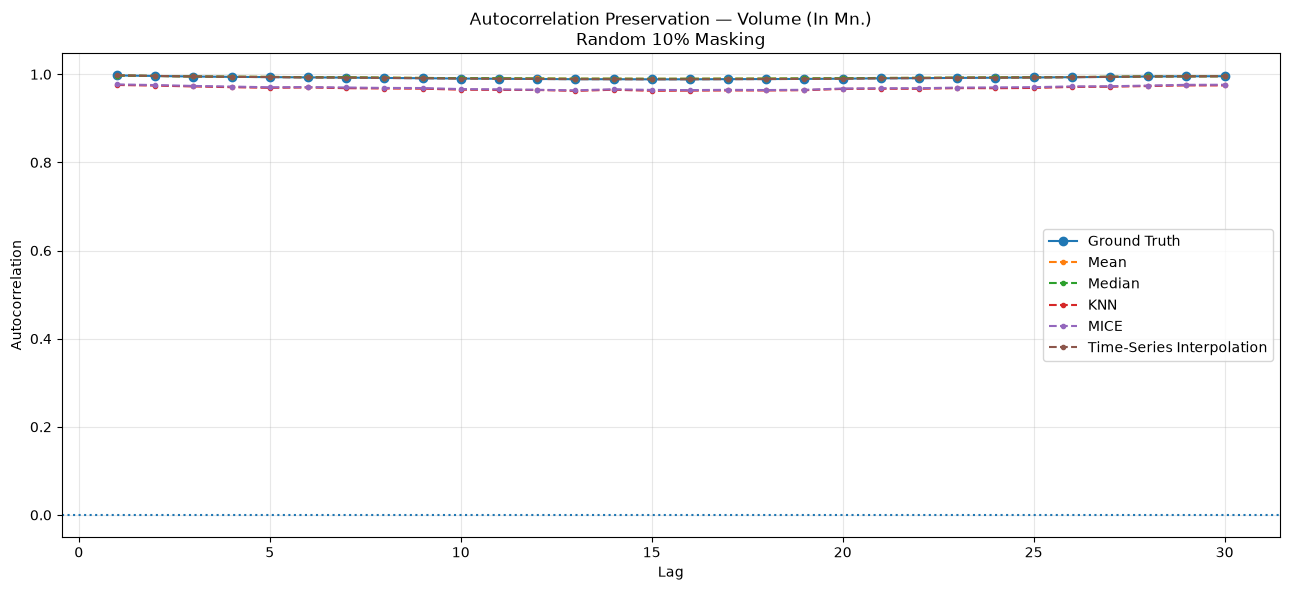

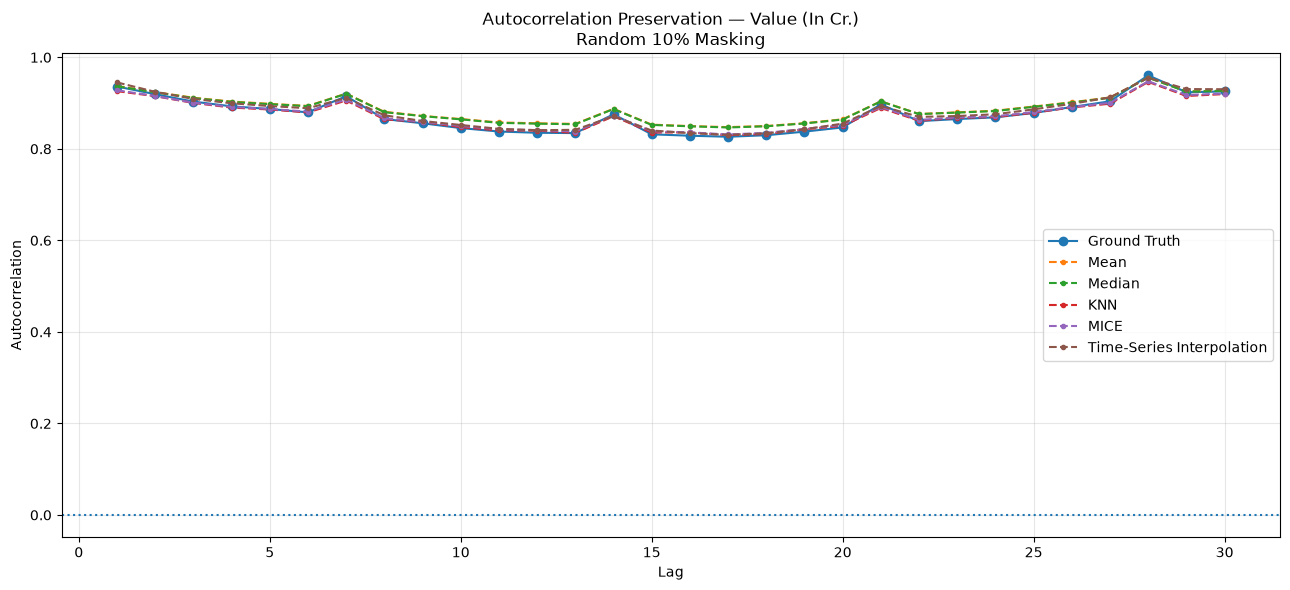


[STEP 11] Comparing random and block masking...
Masking                    Method        Variable  ACF RMSE  ACF MAE  ACF Correlation
  block                       KNN  Value (In Cr.)  0.045389 0.043453         0.968244
  block                       KNN Volume (In Mn.)  0.023766 0.021014         0.306503
  block                      MICE  Value (In Cr.)  0.045389 0.043453         0.968244
  block                      MICE Volume (In Mn.)  0.023766 0.021014         0.306503
  block                      Mean  Value (In Cr.)  0.039496 0.037578         0.968848
  block                      Mean Volume (In Mn.)  0.022465 0.019818         0.307543
  block                    Median  Value (In Cr.)  0.039287 0.037415         0.969611
  block                    Median Volume (In Mn.)  0.021927 0.019350         0.315314
  block Time-Series Interpolation  Value (In Cr.)  0.002624 0.002507         0.999947
  block Time-Series Interpolation Volume (In Mn.)  0.000156 0.000149         0.999985
 rand

In [ ]:
# ============================================================
# STAGE 3C — AUTOCORRELATION PRESERVATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STAGE 3C: AUTOCORRELATION PRESERVATION")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — CHECK PREVIOUS RESULTS
# ------------------------------------------------------------

print("\n[STEP 1] Checking previous-stage results...")

if "imputation_results" not in globals():
    raise RuntimeError(
        "Stage 2 results not found."
    )

if "distribution_results_df" not in globals():
    raise RuntimeError(
        "Stage 3B results not found. "
        "Please run Stage 3B first."
    )

print("✓ Stage 2 results found")
print("✓ Stage 3B results found")
print("✓ Ground truth found")


# ------------------------------------------------------------
# STEP 2 — DEFINE ACF FUNCTION
# ------------------------------------------------------------

print("\n[STEP 2] Defining autocorrelation function...")


def calculate_acf(series, max_lag=30):

    """
    Calculate autocorrelation for lags 1 to max_lag.

    Lag 0 is excluded because it is always equal to 1.
    """

    series = np.asarray(series, dtype=float)

    acf_values = []

    for lag in range(1, max_lag + 1):

        x = series[:-lag]
        y = series[lag:]

        correlation = np.corrcoef(
            x,
            y
        )[0, 1]

        acf_values.append(correlation)

    return np.array(acf_values)


print("✓ ACF function created")
print("  Number of lags = 30")


# ------------------------------------------------------------
# STEP 3 — DEFINE ACF COMPARISON FUNCTION
# ------------------------------------------------------------

print("\n[STEP 3] Defining ACF comparison metrics...")


def compare_acf(
    original_series,
    imputed_series,
    max_lag=30
):

    original_acf = calculate_acf(
        original_series,
        max_lag
    )

    imputed_acf = calculate_acf(
        imputed_series,
        max_lag
    )

    # Difference between original and imputed ACF
    acf_difference = (
        original_acf -
        imputed_acf
    )

    # RMSE of ACF differences
    acf_rmse = np.sqrt(
        np.mean(
            acf_difference ** 2
        )
    )

    # MAE of ACF differences
    acf_mae = np.mean(
        np.abs(
            acf_difference
        )
    )

    # Correlation between ACF curves
    acf_correlation = np.corrcoef(
        original_acf,
        imputed_acf
    )[0, 1]

    return {
        "ACF RMSE": acf_rmse,
        "ACF MAE": acf_mae,
        "ACF Correlation": acf_correlation,
        "Original ACF": original_acf,
        "Imputed ACF": imputed_acf
    }


print("✓ ACF RMSE defined")
print("✓ ACF MAE defined")
print("✓ ACF correlation defined")


# ------------------------------------------------------------
# STEP 4 — EVALUATE ALL EXPERIMENTS
# ------------------------------------------------------------

print("\n[STEP 4] Evaluating temporal structure...")
print("-" * 70)


acf_results = []

methods = [
    "mean",
    "median",
    "knn",
    "mice",
    "interpolation"
]

method_labels = {
    "mean": "Mean",
    "median": "Median",
    "knn": "KNN",
    "mice": "MICE",
    "interpolation": "Time-Series Interpolation"
}


# Store actual ACF curves separately
acf_curves = {}


for masking_type in ["random", "block"]:

    for percentage in [5, 10, 20]:

        print(
            f"\n{masking_type.upper()} MASKING — {percentage}%"
        )

        acf_curves[
            (masking_type, percentage)
        ] = {}

        for column in target_columns:

            # Ground-truth ACF
            original_series = (
                ground_truth[column]
                .values
            )

            acf_curves[
                (masking_type, percentage)
            ][
                column
            ] = {
                "ground_truth":
                    calculate_acf(
                        original_series,
                        max_lag=30
                    )
            }


        for method in methods:

            imputed_data = (
                imputation_results
                [masking_type]
                [percentage]
                [method]
            )

            for column in target_columns:

                original_series = (
                    ground_truth[column]
                    .values
                )

                imputed_series = (
                    imputed_data[column]
                    .values
                )

                comparison = compare_acf(
                    original_series,
                    imputed_series,
                    max_lag=30
                )

                acf_results.append({

                    "Masking":
                        masking_type,

                    "Missingness":
                        percentage,

                    "Method":
                        method_labels[method],

                    "Variable":
                        column,

                    "ACF RMSE":
                        comparison["ACF RMSE"],

                    "ACF MAE":
                        comparison["ACF MAE"],

                    "ACF Correlation":
                        comparison[
                            "ACF Correlation"
                        ]

                })

                acf_curves[
                    (masking_type, percentage)
                ][
                    column
                ][
                    method_labels[method]
                ] = comparison[
                    "Imputed ACF"
                ]

            print(
                f"  ✓ {method_labels[method]}"
            )


acf_df = pd.DataFrame(
    acf_results
)

print("\n✓ ACF evaluation complete")


# ------------------------------------------------------------
# STEP 5 — DISPLAY COMPLETE RESULTS
# ------------------------------------------------------------

print("\n[STEP 5] Complete ACF results")
print("=" * 70)

print(
    acf_df.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 6 — OVERALL ACF PERFORMANCE
# ------------------------------------------------------------

print("\n[STEP 6] Overall temporal preservation...")

acf_summary = (
    acf_df
    .groupby(
        ["Method", "Variable"]
    )[
        [
            "ACF RMSE",
            "ACF MAE",
            "ACF Correlation"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    "\nAverage ACF performance:"
)

print(
    acf_summary.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 7 — ACF RMSE PIVOT
# ------------------------------------------------------------

print("\n[STEP 7] Comparing ACF RMSE...")

acf_rmse_pivot = (
    acf_summary
    .pivot(
        index="Method",
        columns="Variable",
        values="ACF RMSE"
    )
)

print(
    "\nAverage ACF RMSE:"
)

print(
    acf_rmse_pivot.to_string()
)

print(
    "\nLower ACF RMSE = better temporal preservation."
)


# ------------------------------------------------------------
# STEP 8 — ACF MAE PIVOT
# ------------------------------------------------------------

print("\n[STEP 8] Comparing ACF MAE...")

acf_mae_pivot = (
    acf_summary
    .pivot(
        index="Method",
        columns="Variable",
        values="ACF MAE"
    )
)

print(
    "\nAverage ACF MAE:"
)

print(
    acf_mae_pivot.to_string()
)


# ------------------------------------------------------------
# STEP 9 — ACF CORRELATION PIVOT
# ------------------------------------------------------------

print("\n[STEP 9] Comparing ACF correlations...")

acf_corr_pivot = (
    acf_summary
    .pivot(
        index="Method",
        columns="Variable",
        values="ACF Correlation"
    )
)

print(
    "\nAverage ACF Correlation:"
)

print(
    acf_corr_pivot.to_string()
)

print(
    "\nHigher ACF correlation = better temporal preservation."
)


# ------------------------------------------------------------
# STEP 10 — PLOT ACF CURVES
# ------------------------------------------------------------

print("\n[STEP 10] Plotting ACF curves...")

selected_masking = "random"
selected_percentage = 10

lags = np.arange(1, 31)


for column in target_columns:

    plt.figure(figsize=(13, 6))

    ground_truth_acf = (
        acf_curves[
            (
                selected_masking,
                selected_percentage
            )
        ][column]["ground_truth"]
    )

    plt.plot(
        lags,
        ground_truth_acf,
        marker="o",
        label="Ground Truth"
    )

    for method in method_labels.values():

        method_acf = (
            acf_curves[
                (
                    selected_masking,
                    selected_percentage
                )
            ][column][method]
        )

        plt.plot(
            lags,
            method_acf,
            marker=".",
            linestyle="--",
            label=method
        )

    plt.axhline(
        y=0,
        linestyle=":"
    )

    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")

    plt.title(
        f"Autocorrelation Preservation — "
        f"{column}\n"
        f"Random 10% Masking"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# STEP 11 — RANDOM VS BLOCK
# ------------------------------------------------------------

print("\n[STEP 11] Comparing random and block masking...")

acf_masking_summary = (
    acf_df
    .groupby(
        ["Masking", "Method", "Variable"]
    )[
        [
            "ACF RMSE",
            "ACF MAE",
            "ACF Correlation"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    acf_masking_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 12 — SAVE RESULTS
# ------------------------------------------------------------

print("\n[STEP 12] Saving Stage 3C results...")

acf_results_df = acf_df.copy()

acf_summary_df = acf_summary.copy()

acf_rmse_pivot_df = acf_rmse_pivot.copy()

acf_mae_pivot_df = acf_mae_pivot.copy()

acf_corr_pivot_df = acf_corr_pivot.copy()

print("✓ acf_results_df")
print("✓ acf_summary_df")
print("✓ acf_rmse_pivot_df")
print("✓ acf_mae_pivot_df")
print("✓ acf_corr_pivot_df")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 3C COMPLETE")
print("=" * 70)

print("\nTemporal preservation metrics calculated:")
print("  ✓ ACF RMSE")
print("  ✓ ACF MAE")
print("  ✓ ACF Correlation")
print("  ✓ ACF curves")

print("\nInterpretation:")
print("  • Lower ACF RMSE = better")
print("  • Lower ACF MAE = better")
print("  • Higher ACF correlation = better")

print("\nNEXT:")
print("  → Stage 4: Consolidated comparison")
print("  → Rank methods across all metrics")
print("  → Generate final result tables")
print("  → Identify strengths and weaknesses")

print("=" * 70)

STAGE 4: CONSOLIDATED COMPARISON

[STEP 1] Checking previous results...
evaluation_results_df: FOUND
distribution_results_df: FOUND
acf_results_df: FOUND
✓ All previous-stage results available

[STEP 2] Combining all evaluation metrics...
✓ RMSE and MAE added
✓ KS statistic added
✓ Variance preservation added
✓ ACF metrics added

[STEP 3] FINAL CONSOLIDATED RESULTS
                   Method        Variable         RMSE          MAE  KS Statistic  Variance Ratio  ACF RMSE  ACF MAE  ACF Correlation  Variance Error
                      KNN  Value (In Cr.) 22985.175252 21065.407409      0.541515        0.403062  0.028050 0.026233         0.982496        0.596938
                      KNN Volume (In Mn.)   188.742230   173.901961      0.550542        0.421622  0.026880 0.025485         0.638759        0.578378
                     MICE  Value (In Cr.) 22847.109634 20974.845733      0.543541        0.407280  0.027844 0.025951         0.983040        0.592720
                     MICE Volume

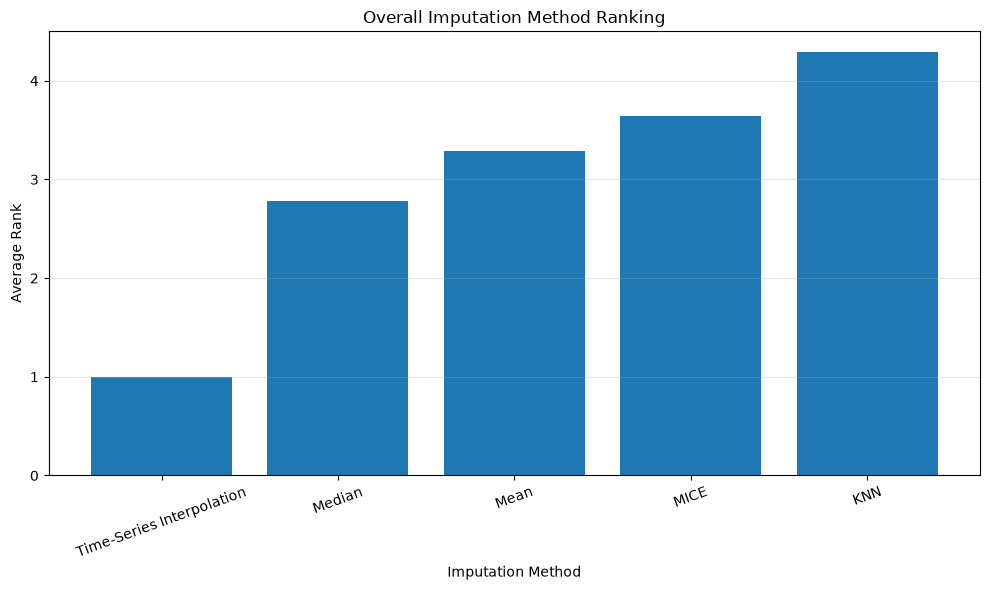


[STEP 9] Saving final results...
✓ final_metrics_df
✓ final_ranking_df
✓ final_variable_ranking_df

STAGE 4 COMPLETE

We now have:
✓ Accuracy evaluation
✓ Distribution evaluation
✓ Variance preservation
✓ Autocorrelation preservation
✓ Overall method ranking
✓ Variable-specific ranking

NEXT:
→ Robustness testing with multiple random seeds
→ Final tables and figures
→ Results + Discussion


In [ ]:
# ============================================================
# STAGE 4 — FINAL CONSOLIDATED COMPARISON
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STAGE 4: CONSOLIDATED COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# STEP 1 — CHECK RESULTS
# ------------------------------------------------------------

print("\n[STEP 1] Checking previous results...")

print("evaluation_results_df:", "FOUND" if "evaluation_results_df" in globals() else "MISSING")
print("distribution_results_df:", "FOUND" if "distribution_results_df" in globals() else "MISSING")
print("acf_results_df:", "FOUND" if "acf_results_df" in globals() else "MISSING")

if "evaluation_results_df" not in globals():
    raise RuntimeError("Stage 3A results are missing.")

if "distribution_results_df" not in globals():
    raise RuntimeError("Stage 3B results are missing.")

if "acf_results_df" not in globals():
    raise RuntimeError("Stage 3C results are missing.")

print("✓ All previous-stage results available")


# ------------------------------------------------------------
# STEP 2 — CREATE CONSOLIDATED TABLE
# ------------------------------------------------------------

print("\n[STEP 2] Combining all evaluation metrics...")

# Accuracy
accuracy = (
    evaluation_results_df
    .groupby(["Method", "Variable"])[["RMSE", "MAE"]]
    .mean()
    .reset_index()
)

# Distribution
distribution = (
    distribution_results_df
    .groupby(["Method", "Variable"])[
        ["KS Statistic", "Variance Ratio"]
    ]
    .mean()
    .reset_index()
)

# Temporal structure
acf = (
    acf_results_df
    .groupby(["Method", "Variable"])[
        ["ACF RMSE", "ACF MAE", "ACF Correlation"]
    ]
    .mean()
    .reset_index()
)

# Merge
final_metrics = accuracy.merge(
    distribution,
    on=["Method", "Variable"]
)

final_metrics = final_metrics.merge(
    acf,
    on=["Method", "Variable"]
)

# Variance error from ideal = 1
final_metrics["Variance Error"] = abs(
    final_metrics["Variance Ratio"] - 1
)

print("✓ RMSE and MAE added")
print("✓ KS statistic added")
print("✓ Variance preservation added")
print("✓ ACF metrics added")


# ------------------------------------------------------------
# STEP 3 — DISPLAY FINAL METRICS
# ------------------------------------------------------------

print("\n[STEP 3] FINAL CONSOLIDATED RESULTS")
print("=" * 70)

print(
    final_metrics.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 4 — RANK METHODS
# ------------------------------------------------------------

print("\n[STEP 4] Ranking methods...")

metrics_lower = [
    "RMSE",
    "MAE",
    "KS Statistic",
    "Variance Error",
    "ACF RMSE",
    "ACF MAE"
]

metrics_higher = [
    "ACF Correlation"
]

ranked = final_metrics.copy()

# Lower = better
for metric in metrics_lower:
    ranked[metric + " Rank"] = (
        ranked.groupby("Variable")[metric]
        .rank(ascending=True, method="min")
    )

# Higher = better
for metric in metrics_higher:
    ranked[metric + " Rank"] = (
        ranked.groupby("Variable")[metric]
        .rank(ascending=False, method="min")
    )

print("✓ All metric rankings calculated")


# ------------------------------------------------------------
# STEP 5 — OVERALL RANKING
# ------------------------------------------------------------

print("\n[STEP 5] Calculating overall ranking...")

rank_columns = [
    "RMSE Rank",
    "MAE Rank",
    "KS Statistic Rank",
    "Variance Error Rank",
    "ACF RMSE Rank",
    "ACF MAE Rank",
    "ACF Correlation Rank"
]

ranked["Average Rank"] = (
    ranked[rank_columns].mean(axis=1)
)

overall = (
    ranked
    .groupby("Method")["Average Rank"]
    .mean()
    .sort_values()
    .reset_index()
)

overall["Overall Rank"] = range(
    1,
    len(overall) + 1
)

print("\n🏆 OVERALL METHOD RANKING")
print("=" * 70)

print(
    overall[
        ["Overall Rank", "Method", "Average Rank"]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# STEP 6 — VARIABLE-SPECIFIC RANKING
# ------------------------------------------------------------

print("\n[STEP 6] Variable-specific ranking...")

variable_ranking = (
    ranked
    .groupby(["Variable", "Method"])["Average Rank"]
    .mean()
    .reset_index()
    .sort_values(["Variable", "Average Rank"])
)

print(
    variable_ranking.to_string(index=False)
)


# ------------------------------------------------------------
# STEP 7 — FIND WINNERS
# ------------------------------------------------------------

print("\n[STEP 7] Finding best method for each metric...")

for variable in ranked["Variable"].unique():

    print("\n" + "-" * 60)
    print("VARIABLE:", variable)
    print("-" * 60)

    data = ranked[
        ranked["Variable"] == variable
    ]

    for metric in metrics_lower:

        best_row = data.loc[
            data[metric].idxmin()
        ]

        print(
            f"{metric}: {best_row['Method']}"
        )

    best_row = data.loc[
        data["ACF Correlation"].idxmax()
    ]

    print(
        f"ACF Correlation: {best_row['Method']}"
    )


# ------------------------------------------------------------
# STEP 8 — OVERALL RANKING PLOT
# ------------------------------------------------------------

print("\n[STEP 8] Creating final ranking plot...")

plt.figure(figsize=(10, 6))

plt.bar(
    overall["Method"],
    overall["Average Rank"]
)

plt.xlabel("Imputation Method")
plt.ylabel("Average Rank")
plt.title("Overall Imputation Method Ranking")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# STEP 9 — SAVE RESULTS
# ------------------------------------------------------------

print("\n[STEP 9] Saving final results...")

final_metrics_df = final_metrics.copy()
final_ranking_df = overall.copy()
final_variable_ranking_df = variable_ranking.copy()

print("✓ final_metrics_df")
print("✓ final_ranking_df")
print("✓ final_variable_ranking_df")


# ------------------------------------------------------------
# COMPLETE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 4 COMPLETE")
print("=" * 70)

print("\nWe now have:")
print("✓ Accuracy evaluation")
print("✓ Distribution evaluation")
print("✓ Variance preservation")
print("✓ Autocorrelation preservation")
print("✓ Overall method ranking")
print("✓ Variable-specific ranking")

print("\nNEXT:")
print("→ Robustness testing with multiple random seeds")
print("→ Final tables and figures")
print("→ Results + Discussion")

print("=" * 70)

STAGE 5: ROBUSTNESS ANALYSIS

[STEP 1] Checking existing experiment setup...
✓ Random masking function found: random_mask_data
✓ Ground truth found
✓ Target columns found
✓ Moving-window Mean/Median function found
✓ KNN function found
✓ MICE function found
✓ Time-Series interpolation found

[STEP 2] Defining robustness experiment...
Seeds:
  - 42
  - 123
  - 456
  - 789
  - 2026

Missingness levels:
  - 5%
  - 10%
  - 20%

Methods:
  - Mean
  - Median
  - KNN
  - MICE
  - Time-Series Interpolation

Total robustness experiments:
  5 seeds × 3 levels × 5 methods
  = 75 imputation runs

[STEP 3] Defining robustness masking...
✓ Independent random masking function created
✓ Masking uses the selected random seed

[STEP 4] Defining robustness evaluation...
✓ RMSE evaluation defined
✓ MAE evaluation defined
✓ Evaluation restricted to masked cells

[STEP 5] Running multiple random masking experiments...

######################################################################
RANDOM SEED = 42
##

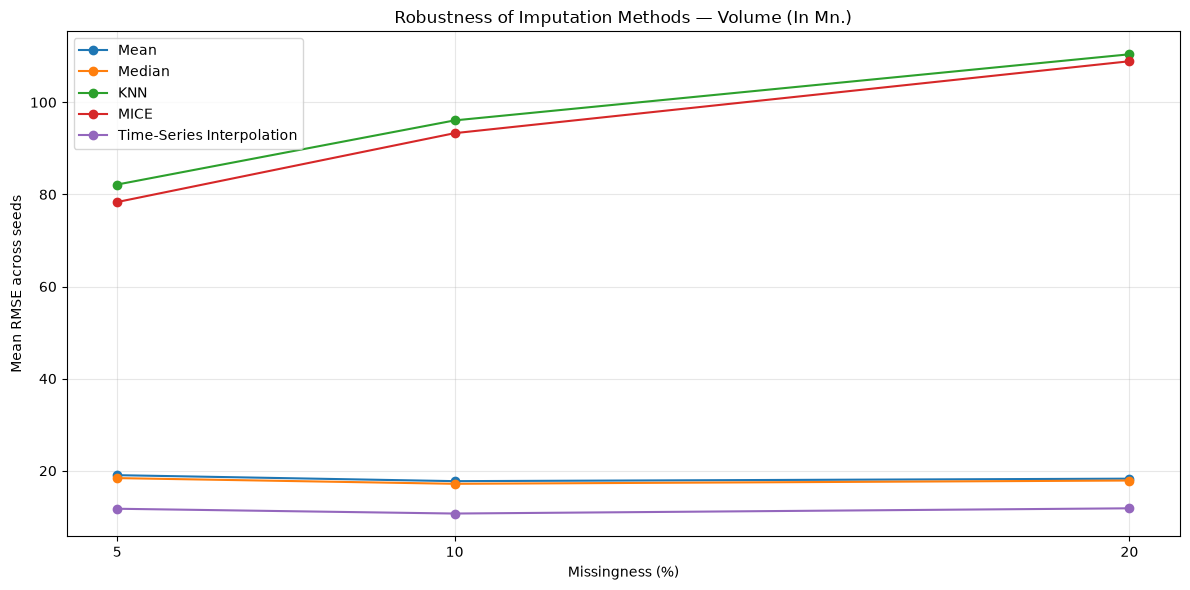

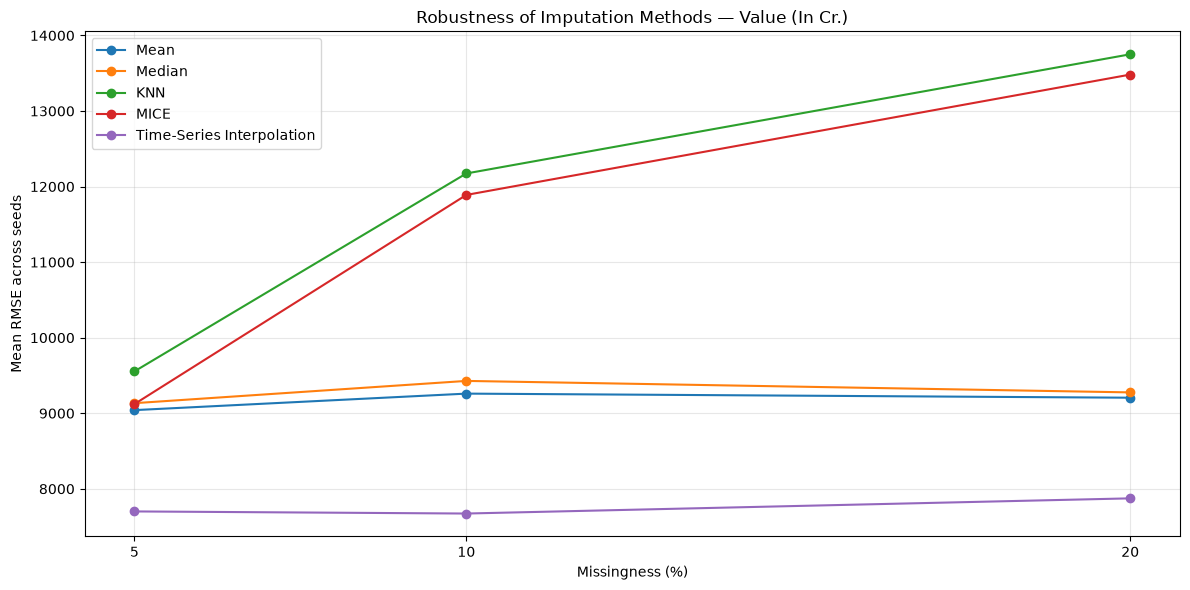


[STEP 14] Examining variability across seeds...
                   Method        Variable  RMSE Std Across Experiments
                      KNN  Value (In Cr.)                  1960.624464
                      KNN Volume (In Mn.)                    13.259331
                     MICE  Value (In Cr.)                  2077.957125
                     MICE Volume (In Mn.)                    14.009904
                     Mean  Value (In Cr.)                   834.871761
                     Mean Volume (In Mn.)                     1.350584
                   Median  Value (In Cr.)                   846.542944
                   Median Volume (In Mn.)                     1.363654
Time-Series Interpolation  Value (In Cr.)                   570.548507
Time-Series Interpolation Volume (In Mn.)                     1.588517

[STEP 15] Saving Stage 5 results...
✓ robustness_results_df
✓ robustness_summary_df
✓ overall_robustness_df
✓ robustness_rank_df
✓ robustness_winners_df

STAGE 5 COMPLET

In [ ]:
# ============================================================
# STAGE 5 — ROBUSTNESS ANALYSIS
# MULTIPLE RANDOM MASKING SEEDS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STAGE 5: ROBUSTNESS ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — CHECK REQUIRED FUNCTIONS AND DATA
# ------------------------------------------------------------

print("\n[STEP 1] Checking existing experiment setup...")

required_objects = [
    "ground_truth",
    "target_columns",
    "moving_stat_imputation",
    "knn_imputation",
    "mice_imputation",
    "time_series_interpolation"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    print("\n❌ Missing objects:")
    for obj in missing_objects:
        print("  -", obj)

    raise RuntimeError(
        "Required Stage 1/2 objects are missing. "
        "Run Stage 1 and Stage 2 first."
    )

# Check the random masking function separately.
# Different versions of Stage 1 may have used different names.

if "random_mask_data" in globals():
    random_mask_function = random_mask_data
    print("✓ Random masking function found: random_mask_data")

elif "create_random_mask" in globals():
    random_mask_function = create_random_mask
    print("✓ Random masking function found: create_random_mask")

elif "random_masking" in globals():
    random_mask_function = random_masking
    print("✓ Random masking function found: random_masking")

else:
    random_mask_function = None
    print("⚠ No random masking function found.")
    print("  Robustness masking will be created directly in Stage 5.")


print("✓ Ground truth found")
print("✓ Target columns found")
print("✓ Moving-window Mean/Median function found")
print("✓ KNN function found")
print("✓ MICE function found")
print("✓ Time-Series interpolation found")


# ------------------------------------------------------------
# STEP 2 — DEFINE ROBUSTNESS EXPERIMENT
# ------------------------------------------------------------

print("\n[STEP 2] Defining robustness experiment...")

seeds = [
    42,
    123,
    456,
    789,
    2026
]

missingness_levels = [
    5,
    10,
    20
]

methods = [
    "mean",
    "median",
    "knn",
    "mice",
    "interpolation"
]

method_labels = {
    "mean": "Mean",
    "median": "Median",
    "knn": "KNN",
    "mice": "MICE",
    "interpolation": "Time-Series Interpolation"
}

print("Seeds:")
for seed in seeds:
    print(f"  - {seed}")

print("\nMissingness levels:")
for level in missingness_levels:
    print(f"  - {level}%")

print("\nMethods:")
for method in methods:
    print(f"  - {method_labels[method]}")

print("\nTotal robustness experiments:")
print(
    f"  {len(seeds)} seeds × "
    f"{len(missingness_levels)} levels × "
    f"{len(methods)} methods"
)

print(
    f"  = {len(seeds) * len(missingness_levels) * len(methods)} "
    "imputation runs"
)


# ------------------------------------------------------------
# STEP 3 — DEFINE RANDOM MASKING FOR ROBUSTNESS
# ------------------------------------------------------------

print("\n[STEP 3] Defining robustness masking...")

def create_robustness_mask(data, columns, percentage, seed):
    """
    Randomly masks individual cells in the selected numerical
    columns while preserving the Day column.

    The same masking design is used for every seed so that
    different random seeds produce independent masking patterns.
    """

    rng = np.random.default_rng(seed)

    masked_data = data.copy()

    n_rows = len(data)
    n_columns = len(columns)

    total_cells = n_rows * n_columns

    n_to_mask = int(round(
        total_cells * percentage / 100
    ))

    # Randomly select cells
    selected_cells = rng.choice(
        total_cells,
        size=n_to_mask,
        replace=False
    )

    mask = pd.DataFrame(
        False,
        index=data.index,
        columns=columns
    )

    for cell in selected_cells:

        row_position = cell // n_columns
        column_position = cell % n_columns

        row_index = data.index[row_position]
        column_name = columns[column_position]

        mask.loc[
            row_index,
            column_name
        ] = True

        masked_data.loc[
            row_index,
            column_name
        ] = np.nan

    return masked_data, mask


print("✓ Independent random masking function created")
print("✓ Masking uses the selected random seed")


# ------------------------------------------------------------
# STEP 4 — DEFINE RMSE / MAE FUNCTION
# ------------------------------------------------------------

print("\n[STEP 4] Defining robustness evaluation...")

def calculate_error_metrics(
    original,
    imputed,
    mask,
    columns
):
    """
    Calculate RMSE and MAE only on artificially
    masked cells.
    """

    results = []

    for column in columns:

        masked_positions = mask[column]

        original_values = original.loc[
            masked_positions,
            column
        ].values

        imputed_values = imputed.loc[
            masked_positions,
            column
        ].values

        errors = (
            imputed_values -
            original_values
        )

        rmse = np.sqrt(
            np.mean(
                errors ** 2
            )
        )

        mae = np.mean(
            np.abs(errors)
        )

        results.append({
            "Variable": column,
            "RMSE": rmse,
            "MAE": mae,
            "N_Masked": len(original_values)
        })

    return results


print("✓ RMSE evaluation defined")
print("✓ MAE evaluation defined")
print("✓ Evaluation restricted to masked cells")


# ------------------------------------------------------------
# STEP 5 — RUN ROBUSTNESS EXPERIMENT
# ------------------------------------------------------------

print("\n[STEP 5] Running multiple random masking experiments...")
print("=" * 70)

robustness_results = []


for seed in seeds:

    print(f"\n{'#' * 70}")
    print(f"RANDOM SEED = {seed}")
    print(f"{'#' * 70}")

    for percentage in missingness_levels:

        print(
            f"\n--- Random masking: {percentage}% ---"
        )


        # ----------------------------------------------------
        # CREATE NEW RANDOM MASK
        # ----------------------------------------------------

        masked_data, mask = create_robustness_mask(
            ground_truth,
            target_columns,
            percentage,
            seed
        )

        total_masked = (
            mask[target_columns]
            .sum()
            .sum()
        )

        print(
            f"Cells masked: {total_masked}"
        )


        # ----------------------------------------------------
        # MEAN
        # ----------------------------------------------------

        print("  [1/5] Mean...")

        mean_result = moving_stat_imputation(
            masked_data,
            target_columns,
            window=30,
            statistic="mean"
        )

        metrics = calculate_error_metrics(
            ground_truth,
            mean_result,
            mask,
            target_columns
        )

        for row in metrics:

            robustness_results.append({
                "Seed": seed,
                "Masking": "random",
                "Missingness": percentage,
                "Method": "Mean",
                "Variable": row["Variable"],
                "RMSE": row["RMSE"],
                "MAE": row["MAE"],
                "N_Masked": row["N_Masked"]
            })

        print("       ✓ Complete")


        # ----------------------------------------------------
        # MEDIAN
        # ----------------------------------------------------

        print("  [2/5] Median...")

        median_result = moving_stat_imputation(
            masked_data,
            target_columns,
            window=30,
            statistic="median"
        )

        metrics = calculate_error_metrics(
            ground_truth,
            median_result,
            mask,
            target_columns
        )

        for row in metrics:

            robustness_results.append({
                "Seed": seed,
                "Masking": "random",
                "Missingness": percentage,
                "Method": "Median",
                "Variable": row["Variable"],
                "RMSE": row["RMSE"],
                "MAE": row["MAE"],
                "N_Masked": row["N_Masked"]
            })

        print("       ✓ Complete")


        # ----------------------------------------------------
        # KNN
        # ----------------------------------------------------

        print("  [3/5] KNN...")

        knn_result = knn_imputation(
            masked_data,
            target_columns,
            n_neighbors=5
        )

        metrics = calculate_error_metrics(
            ground_truth,
            knn_result,
            mask,
            target_columns
        )

        for row in metrics:

            robustness_results.append({
                "Seed": seed,
                "Masking": "random",
                "Missingness": percentage,
                "Method": "KNN",
                "Variable": row["Variable"],
                "RMSE": row["RMSE"],
                "MAE": row["MAE"],
                "N_Masked": row["N_Masked"]
            })

        print("       ✓ Complete")


        # ----------------------------------------------------
        # MICE
        # ----------------------------------------------------

        print("  [4/5] MICE...")

        mice_result = mice_imputation(
            masked_data,
            target_columns
        )

        metrics = calculate_error_metrics(
            ground_truth,
            mice_result,
            mask,
            target_columns
        )

        for row in metrics:

            robustness_results.append({
                "Seed": seed,
                "Masking": "random",
                "Missingness": percentage,
                "Method": "MICE",
                "Variable": row["Variable"],
                "RMSE": row["RMSE"],
                "MAE": row["MAE"],
                "N_Masked": row["N_Masked"]
            })

        print("       ✓ Complete")


        # ----------------------------------------------------
        # TIME-SERIES INTERPOLATION
        # ----------------------------------------------------

        print("  [5/5] Time-Series Interpolation...")

        interpolation_result = time_series_interpolation(
            masked_data,
            target_columns
        )

        metrics = calculate_error_metrics(
            ground_truth,
            interpolation_result,
            mask,
            target_columns
        )

        for row in metrics:

            robustness_results.append({
                "Seed": seed,
                "Masking": "random",
                "Missingness": percentage,
                "Method": "Time-Series Interpolation",
                "Variable": row["Variable"],
                "RMSE": row["RMSE"],
                "MAE": row["MAE"],
                "N_Masked": row["N_Masked"]
            })

        print("       ✓ Complete")


# ------------------------------------------------------------
# STEP 6 — CREATE RESULTS DATAFRAME
# ------------------------------------------------------------

print("\n[STEP 6] Creating robustness results table...")

robustness_df = pd.DataFrame(
    robustness_results
)

print("✓ Results dataframe created")

print("\nTotal evaluations:")
print(len(robustness_df))

expected = (
    len(seeds)
    * len(missingness_levels)
    * len(methods)
    * len(target_columns)
)

print("\nExpected:")
print(expected)

if len(robustness_df) == expected:
    print("✓ Evaluation count is correct")
else:
    print("⚠ Evaluation count does not match expected count")


# ------------------------------------------------------------
# STEP 7 — DISPLAY RESULTS
# ------------------------------------------------------------

print("\n[STEP 7] Sample robustness results...")
print("=" * 70)

print(
    robustness_df.head(20).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 8 — AVERAGE PERFORMANCE ACROSS SEEDS
# ------------------------------------------------------------

print(
    "\n[STEP 8] Calculating average performance "
    "across random seeds..."
)

robustness_summary = (
    robustness_df
    .groupby(
        [
            "Method",
            "Missingness",
            "Variable"
        ]
    )[
        [
            "RMSE",
            "MAE"
        ]
    ]
    .agg(
        ["mean", "std"]
    )
    .reset_index()
)

print("\nAverage ± Standard Deviation:")

print(
    robustness_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 9 — OVERALL ROBUSTNESS PERFORMANCE
# ------------------------------------------------------------

print(
    "\n[STEP 9] Calculating overall robustness..."
)

overall_robustness = (
    robustness_df
    .groupby(
        [
            "Method",
            "Variable"
        ]
    )[
        [
            "RMSE",
            "MAE"
        ]
    ]
    .agg(
        ["mean", "std"]
    )
    .reset_index()
)

print(
    "\nOverall performance across ALL seeds "
    "and missingness levels:"
)

print(
    overall_robustness.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 10 — RANK METHODS FOR EACH SEED
# ------------------------------------------------------------

print(
    "\n[STEP 10] Checking ranking stability..."
)

seed_rank_data = (
    robustness_df
    .groupby(
        [
            "Seed",
            "Missingness",
            "Method",
            "Variable"
        ]
    )[
        [
            "RMSE",
            "MAE"
        ]
    ]
    .mean()
    .reset_index()
)

seed_rank_data["RMSE Rank"] = (
    seed_rank_data
    .groupby(
        [
            "Seed",
            "Missingness",
            "Variable"
        ]
    )["RMSE"]
    .rank(
        ascending=True,
        method="min"
    )
)

seed_rank_data["MAE Rank"] = (
    seed_rank_data
    .groupby(
        [
            "Seed",
            "Missingness",
            "Variable"
        ]
    )["MAE"]
    .rank(
        ascending=True,
        method="min"
    )
)

seed_rank_data["Average Rank"] = (
    seed_rank_data[
        [
            "RMSE Rank",
            "MAE Rank"
        ]
    ].mean(axis=1)
)


# ------------------------------------------------------------
# STEP 11 — COUNT FIRST-PLACE FINISHES
# ------------------------------------------------------------

print(
    "\n[STEP 11] Counting first-place finishes..."
)

first_place_counts = []

for seed in seeds:

    for percentage in missingness_levels:

        for variable in target_columns:

            subset = seed_rank_data[
                (seed_rank_data["Seed"] == seed)
                &
                (
                    seed_rank_data["Missingness"]
                    == percentage
                )
                &
                (
                    seed_rank_data["Variable"]
                    == variable
                )
            ]

            best_rank = subset[
                "Average Rank"
            ].min()

            winners = subset[
                subset["Average Rank"]
                == best_rank
            ]["Method"]

            for method in winners:

                first_place_counts.append({
                    "Seed": seed,
                    "Missingness": percentage,
                    "Variable": variable,
                    "Winner": method
                })


winner_df = pd.DataFrame(
    first_place_counts
)

winner_counts = (
    winner_df["Winner"]
    .value_counts()
)

print("\nFirst-place finishes:")

print(
    winner_counts.to_string()
)


# ------------------------------------------------------------
# STEP 12 — CHECK TIME-SERIES WIN RATE
# ------------------------------------------------------------

print(
    "\n[STEP 12] Testing Time-Series Interpolation "
    "ranking stability..."
)

total_comparisons = (
    len(seeds)
    * len(missingness_levels)
    * len(target_columns)
)

timeseries_wins = (
    winner_df["Winner"]
    .eq("Time-Series Interpolation")
    .sum()
)

print(
    "\nTime-Series Interpolation wins:"
)

print(
    f"  {timeseries_wins} / "
    f"{total_comparisons} comparisons"
)

print(
    f"  Win rate = "
    f"{100 * timeseries_wins / total_comparisons:.2f}%"
)

if timeseries_wins == total_comparisons:

    print(
        "\n🏆 RESULT: Time-Series Interpolation "
        "won EVERY robustness comparison."
    )

else:

    print(
        "\nResult: At least one comparison "
        "was won by another method."
    )

    print(
        "\nWinning methods:"
    )

    print(
        winner_counts.to_string()
    )


# ------------------------------------------------------------
# STEP 13 — RMSE ROBUSTNESS PLOTS
# ------------------------------------------------------------

print(
    "\n[STEP 13] Creating robustness plots..."
)

for variable in target_columns:

    plt.figure(
        figsize=(12, 6)
    )

    plot_data = (
        robustness_df[
            robustness_df["Variable"]
            == variable
        ]
        .groupby(
            [
                "Missingness",
                "Method"
            ]
        )["RMSE"]
        .mean()
        .reset_index()
    )

    for method in method_labels.values():

        method_data = plot_data[
            plot_data["Method"]
            == method
        ]

        plt.plot(
            method_data["Missingness"],
            method_data["RMSE"],
            marker="o",
            label=method
        )

    plt.xlabel(
        "Missingness (%)"
    )

    plt.ylabel(
        "Mean RMSE across seeds"
    )

    plt.title(
        f"Robustness of Imputation Methods — "
        f"{variable}"
    )

    plt.xticks(
        [5, 10, 20]
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# STEP 14 — STANDARD DEVIATION
# ------------------------------------------------------------

print(
    "\n[STEP 14] Examining variability across seeds..."
)

seed_variability = (
    robustness_df
    .groupby(
        [
            "Method",
            "Variable"
        ]
    )["RMSE"]
    .std()
    .reset_index()
    .rename(
        columns={
            "RMSE":
            "RMSE Std Across Experiments"
        }
    )
)

print(
    seed_variability.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# STEP 15 — SAVE ROBUSTNESS RESULTS
# ------------------------------------------------------------

print(
    "\n[STEP 15] Saving Stage 5 results..."
)

robustness_results_df = robustness_df.copy()

robustness_summary_df = (
    robustness_summary.copy()
)

overall_robustness_df = (
    overall_robustness.copy()
)

robustness_rank_df = (
    seed_rank_data.copy()
)

robustness_winners_df = (
    winner_df.copy()
)

print("✓ robustness_results_df")
print("✓ robustness_summary_df")
print("✓ overall_robustness_df")
print("✓ robustness_rank_df")
print("✓ robustness_winners_df")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STAGE 5 COMPLETE")
print("=" * 70)

print("\nRobustness experiment completed.")

print(
    f"✓ {len(seeds)} random seeds"
)

print(
    f"✓ {len(missingness_levels)} missingness levels"
)

print(
    f"✓ {len(methods)} imputation methods"
)

print(
    f"✓ {len(target_columns)} variables"
)

print(
    f"✓ {len(robustness_df)} metric evaluations"
)

print("\nNext:")
print(
    "→ Examine whether the Time-Series result "
    "is stable across random seeds"
)

print(
    "→ If robust, prepare final research tables"
)

print(
    "→ Then move to Results + Discussion"
)

print("=" * 70)